In [1]:
%matplotlib widget

# DT 9-layered models NEW

In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
from pickle import dump , load
from numpy.random import seed
import os
from xgboost import plot_tree
from xgboost import plot_importance
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

import sys

sys.path.insert(1, '../../src')

from FDEM import FDEM
plt.style.use('bmh')


/tmp/ipykernel_1337655/765778282.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# 1. Generate regularly sampled models

#sigmas = np.logspace(0,3,9)/1000
h1 = np.logspace(-0.3,0.35,8)



In [4]:
models_log = np.load('Models/models_log_9layers_new400_noextremes.npy')
data = np.load('Data/data_9layers_new400_noextremes.npy')

In [5]:
# 4. Create dataframe

Data = pd.DataFrame(np.hstack((models_log,  data)), 
                    columns = ['logs1', 'logs2', 'logs3', 'logs4', 'logs5', 'logs6','logs7', 'logs8', 'logs9',
                               'h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 
                               'v2op', 'v4op', 'v8op', 'v2ip', 'v4ip', 'v8ip', 
                               'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip'])

In [6]:

Data

,logs1,logs2,logs3,logs4,logs5,logs6,logs7,logs8,logs9,h2op,...,v8op,v2ip,v4ip,v8ip,p2op,p4op,p8op,p2ip,p4ip,p8ip
0,-0.106081,-1.885545,-1.113576,-2.511262,-1.206787,-0.149517,-2.721749,-1.605548,-0.150010,-0.055305,...,0.400040,-0.031953,-0.158464,-0.344357,0.017170,0.048370,0.162722,0.000674,0.006122,0.057911
1,-2.116695,-1.379970,-1.335776,-1.633993,-2.043629,-0.391030,-0.073167,-0.649284,-1.844915,0.003993,...,0.074859,0.000911,0.006988,0.048072,0.002572,0.017585,0.116967,0.000269,0.003958,0.048277
2,-0.967026,-2.534019,-2.586473,-0.294366,-2.593079,-1.382384,-2.606301,-0.781173,-2.562198,-0.006564,...,-0.012109,-0.001835,-0.012478,-0.070454,0.004667,0.026284,0.111513,0.000141,0.001705,0.015621
3,-1.244837,-1.969821,-2.430327,-0.139425,-1.777314,-2.255199,-1.428430,-0.315323,-2.628453,0.001396,...,0.044708,-0.000110,-0.000648,-0.003610,0.004960,0.034218,0.154651,0.000280,0.003553,0.034612
4,-0.577868,-1.592162,-2.981527,-0.422337,-0.149541,-2.218785,-0.950419,-2.716273,-1.272836,-0.017975,...,0.059692,-0.006675,-0.040660,-0.173048,0.009008,0.044449,0.196227,0.000454,0.005559,0.052052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399995,-2.447186,-2.459580,-1.502148,-1.796253,-2.493216,-2.648714,-1.930473,-0.282713,-1.246778,0.001217,...,0.026464,0.000257,0.002018,0.015032,0.000735,0.005173,0.036329,0.000051,0.000783,0.010911
399996,-0.174595,-0.186218,-1.510781,-0.647247,-2.752919,-2.543610,-2.510036,-0.666783,-0.341706,-0.040587,...,0.348186,-0.025418,-0.132049,-0.337440,0.030217,0.086664,0.213490,0.001290,0.009336,0.061463
399997,-1.548166,-2.666848,-1.616668,-2.875530,-2.066613,-0.377800,-0.280010,-1.529897,-0.932656,-0.000145,...,0.027196,0.000329,0.002631,0.019071,0.001551,0.011844,0.090484,0.000165,0.002448,0.030734
399998,-1.324192,-1.516824,-1.466604,-2.191677,-1.504063,-2.808287,-2.149927,-0.793650,-1.894619,-0.004063,...,-0.036029,-0.000596,-0.004295,-0.027506,0.002192,0.008046,0.031051,0.000017,0.000208,0.002506


In [7]:
Data['h2'] = Data['h2op'] +1j*Data['h2ip']
Data['h4'] = Data['h4op'] +1j*Data['h4ip']
Data['h8'] = Data['h8op'] +1j*Data['h8ip']

Data['v2'] = Data['v2op'] +1j*Data['v2ip']
Data['v4'] = Data['v4op'] +1j*Data['v4ip']
Data['v8'] = Data['v8op'] +1j*Data['v8ip']

Data['p2'] = Data['p2op'] +1j*Data['p2ip']
Data['p4'] = Data['p4op'] +1j*Data['p4ip']
Data['p8'] = Data['p8op'] +1j*Data['p8ip']


In [8]:
Data['h2amp'] = np.log10(np.abs(Data['h2']))
Data['h4amp'] = np.log10(np.abs(Data['h4']))
Data['h8amp'] = np.log10(np.abs(Data['h8']))

Data['v2amp'] = np.log10(np.abs(Data['v2']))
Data['v4amp'] = np.log10(np.abs(Data['v4']))
Data['v8amp'] = np.log10(np.abs(Data['v8']))

Data['p2amp'] = np.log10(np.abs(Data['p2']))
Data['p4amp'] = np.log10(np.abs(Data['p4']))
Data['p8amp'] = np.log10(np.abs(Data['p8']))

In [9]:
Data['h2pha'] = np.angle(Data['h2'])
Data['h4pha'] = np.angle(Data['h4'])
Data['h8pha'] = np.angle(Data['h8'])

Data['v2pha'] = np.angle(Data['v2'])
Data['v4pha'] = np.angle(Data['v4'])
Data['v8pha'] = np.angle(Data['v8'])

Data['p2pha'] = np.angle(Data['p2'])
Data['p4pha'] = np.angle(Data['p4'])
Data['p8pha'] = np.angle(Data['p8'])

In [10]:
# Shuffle the dataset

Data = Data.sample(frac=1, random_state=42)

Data

,logs1,logs2,logs3,logs4,logs5,logs6,logs7,logs8,logs9,h2op,...,p8amp,h2pha,h4pha,h8pha,v2pha,v4pha,v8pha,p2pha,p4pha,p8pha
23218,-1.978785,-1.433470,-1.899466,-1.019927,-0.302287,-1.000180,-1.508322,-2.918281,-2.102589,0.004083,...,-0.941946,0.176397,0.236371,0.450248,0.167344,0.176879,0.235913,0.047267,0.087342,0.164004
20731,-0.023031,-0.615529,-2.430619,-0.478312,-0.540936,-1.470410,-0.615139,-0.079644,-0.743309,-0.057417,...,-0.592990,-2.561165,-1.866256,-0.490295,-2.536758,-1.770743,-0.481707,0.049841,0.141289,0.369916
39555,-1.054286,-0.576430,-2.901485,-2.853509,-1.659254,-1.581410,-0.581446,-1.687498,-2.124398,-0.004840,...,-1.095415,-2.907987,-2.768960,-2.327545,-2.858590,-2.560227,-1.951534,0.013810,0.039701,0.115190
147506,-2.151020,-1.206595,-1.558532,-1.263939,-1.185329,-2.352526,-0.546143,-1.988016,-1.512095,0.002382,...,-1.219806,0.148432,0.254589,0.448812,0.103548,0.149436,0.233380,0.018639,0.051909,0.131186
314215,-2.573905,-0.895835,-0.091109,-0.293930,-1.178301,-2.541166,-2.440305,-0.735052,-2.110651,0.018913,...,-0.571802,0.155979,0.309542,0.808351,0.117829,0.176170,0.303610,0.058448,0.113866,0.250622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,-2.125908,-0.055175,-2.174097,-2.266694,-0.821176,-0.442739,-0.373523,-1.439273,-0.522111,0.016117,...,-0.626087,0.183659,0.492986,1.046610,0.093998,0.185559,0.378872,0.039011,0.107840,0.299646
365838,-1.143052,-0.829531,-2.708844,-1.086741,-0.179383,-0.626730,-1.348452,-1.954474,-0.556190,-0.000191,...,-0.758111,1.824789,0.727507,1.115217,-3.049352,-1.303593,-0.125851,0.049011,0.126804,0.277488
131932,-1.669678,-1.843557,-2.018901,-2.071114,-2.607874,-2.353634,-0.378447,-2.533805,-0.323043,-0.000865,...,-1.289501,2.459810,1.479778,1.166246,2.986942,2.590212,1.303789,0.084201,0.227029,0.412867
146867,-2.751270,-0.952905,-0.497326,-0.693158,-0.910591,-1.888221,-1.105874,-1.638389,-1.369449,0.009453,...,-0.852199,0.101872,0.208430,0.523176,0.072659,0.114873,0.208122,0.028733,0.062125,0.148135


In [11]:
# Scale here

Data_X = Data.drop(['logs1', 'logs2', 'logs3', 'logs4', 'logs5', 'logs6','logs7', 'logs8', 'logs9',
                   'h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 
                   'v2op', 'v4op', 'v8op', 'v2ip', 'v4ip', 'v8ip', 
                   'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip',
                    'h2', 'h4', 'h8', 'v2', 'v4', 'v8', 'p2', 'p4', 'p8'
                   ], axis=1)
Data_X

,h2amp,h4amp,h8amp,v2amp,v4amp,v8amp,p2amp,p4amp,p8amp,h2pha,h4pha,h8pha,v2pha,v4pha,v8pha,p2pha,p4pha,p8pha
23218,-2.382260,-1.662774,-1.195982,-2.696918,-1.848264,-1.163515,-2.547010,-1.681961,-0.941946,0.176397,0.236371,0.450248,0.167344,0.176879,0.235913,0.047267,0.087342,0.164004
20731,-1.163284,-0.740921,-0.267837,-1.149326,-0.717920,-0.181285,-1.574411,-1.096382,-0.592990,-2.561165,-1.866256,-0.490295,-2.536758,-1.770743,-0.481707,0.049841,0.141289,0.369916
39555,-2.303175,-1.643591,-1.167471,-2.300315,-1.749182,-1.206989,-2.076169,-1.583557,-1.095415,-2.907987,-2.768960,-2.327545,-2.858590,-2.560227,-1.951534,0.013810,0.039701,0.115190
147506,-2.618213,-1.977305,-1.396210,-2.810667,-2.082833,-1.419360,-2.600537,-1.904350,-1.219806,0.148432,0.254589,0.448812,0.103548,0.149436,0.233380,0.018639,0.051909,0.131186
314215,-1.717945,-1.236533,-0.971429,-1.867412,-1.211268,-0.700475,-1.830995,-1.098223,-0.571802,0.155979,0.309542,0.808351,0.117829,0.176170,0.303610,0.058448,0.113866,0.250622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,-1.785356,-1.404403,-0.952999,-1.760436,-1.228066,-0.754037,-1.648432,-1.120746,-0.626087,0.183659,0.492986,1.046610,0.093998,0.185559,0.378872,0.039011,0.107840,0.299646
365838,-3.118519,-2.115625,-1.585148,-2.584746,-2.860754,-1.377653,-2.154031,-1.445385,-0.758111,1.824789,0.727507,1.115217,-3.049352,-1.303593,-0.125851,0.049011,0.126804,0.277488
131932,-2.953282,-2.267240,-1.411202,-2.793942,-2.418351,-1.803598,-2.931316,-2.175380,-1.289501,2.459810,1.479778,1.166246,2.986942,2.590212,1.303789,0.084201,0.227029,0.412867
146867,-2.022192,-1.516313,-1.170837,-2.156394,-1.503911,-0.968506,-2.119663,-1.406743,-0.852199,0.101872,0.208430,0.523176,0.072659,0.114873,0.208122,0.028733,0.062125,0.148135


In [12]:
Data_y = Data.drop(['h2amp', 'h4amp', 'h8amp', 'h2pha', 'h4pha', 'h8pha', 
                    'v2amp', 'v4amp', 'v8amp', 'v2pha', 'v4pha', 'v8pha', 
                    'p2amp', 'p4amp', 'p8amp', 'p2pha', 'p4pha', 'p8pha',
                    'h2op', 'h4op', 'h8op', 'h2ip', 'h4ip', 'h8ip', 
                    'v2op', 'v4op', 'v8op', 'v2ip', 'v4ip', 'v8ip', 
                    'p2op', 'p4op', 'p8op', 'p2ip', 'p4ip', 'p8ip',
                    'h2', 'h4', 'h8', 'v2', 'v4', 'v8', 'p2', 'p4', 'p8'
                   ], axis=1)

Data_y

,logs1,logs2,logs3,logs4,logs5,logs6,logs7,logs8,logs9
23218,-1.978785,-1.433470,-1.899466,-1.019927,-0.302287,-1.000180,-1.508322,-2.918281,-2.102589
20731,-0.023031,-0.615529,-2.430619,-0.478312,-0.540936,-1.470410,-0.615139,-0.079644,-0.743309
39555,-1.054286,-0.576430,-2.901485,-2.853509,-1.659254,-1.581410,-0.581446,-1.687498,-2.124398
147506,-2.151020,-1.206595,-1.558532,-1.263939,-1.185329,-2.352526,-0.546143,-1.988016,-1.512095
314215,-2.573905,-0.895835,-0.091109,-0.293930,-1.178301,-2.541166,-2.440305,-0.735052,-2.110651
...,...,...,...,...,...,...,...,...,...
259178,-2.125908,-0.055175,-2.174097,-2.266694,-0.821176,-0.442739,-0.373523,-1.439273,-0.522111
365838,-1.143052,-0.829531,-2.708844,-1.086741,-0.179383,-0.626730,-1.348452,-1.954474,-0.556190
131932,-1.669678,-1.843557,-2.018901,-2.071114,-2.607874,-2.353634,-0.378447,-2.533805,-0.323043
146867,-2.751270,-0.952905,-0.497326,-0.693158,-0.910591,-1.888221,-1.105874,-1.638389,-1.369449


In [13]:
# Scale data

## data normalization
scale_X = MinMaxScaler()
scale_y = MinMaxScaler()

X_norm = scale_X.fit_transform(Data_X)
y_norm = scale_y.fit_transform(Data_y)

In [14]:
# First split: train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)

# Second split: train and val from what's left
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

X_train, X_train_rs, y_train, y_train_rs = train_test_split(X_train, y_train, test_size = 0.01, random_state=42) 


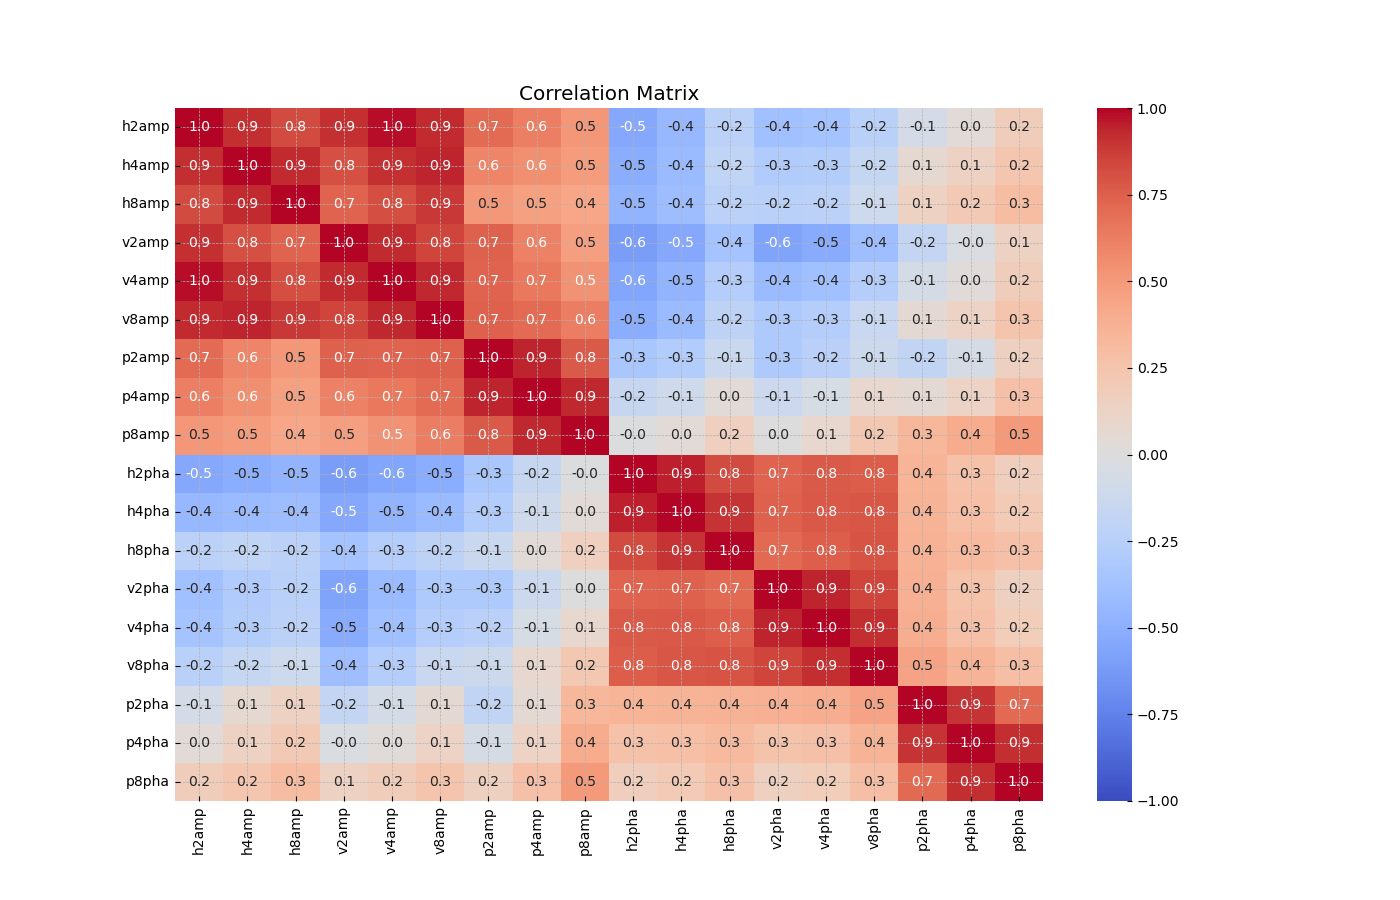

In [15]:
corr_matrix = Data_X.corr()

# Plot heatmap
plt.figure(figsize=(14, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.1f')
plt.title('Correlation Matrix')
plt.show()

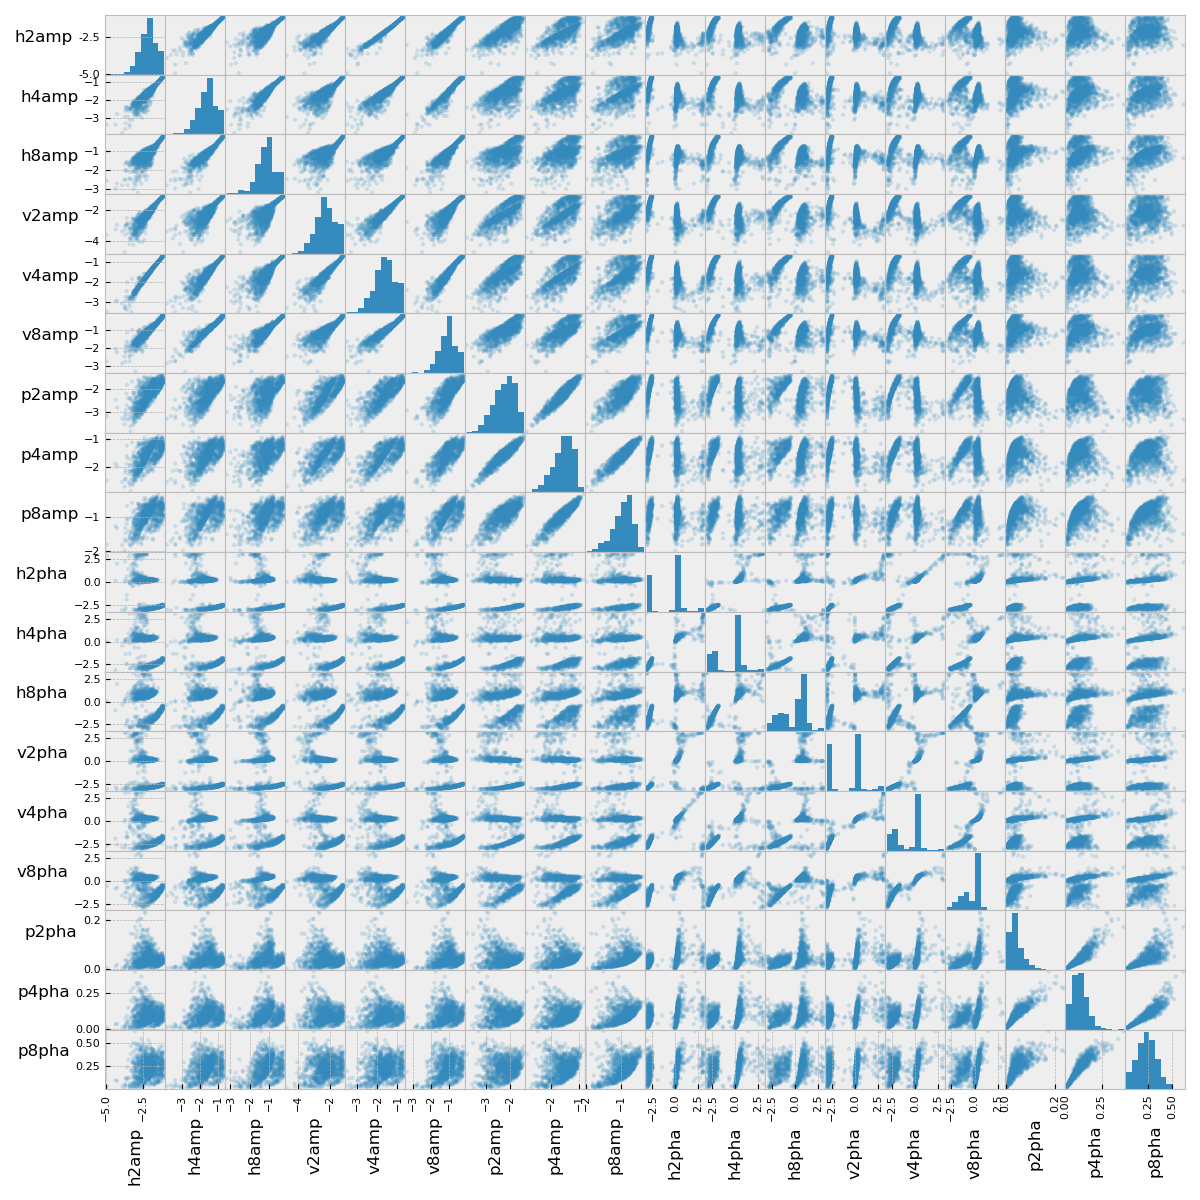

In [16]:
datasamp = Data_X.sample(1000)

axes = pd.plotting.scatter_matrix(datasamp, alpha=0.2, figsize =(12,12))
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

# Search best decision tree

In [14]:


def train_multioutput_xgb(
    X_train_rs, y_train_rs,
    X_train, y_train,
    X_val, y_val,
    param_dist=None,
    n_iter=20,
    cv=5,
    early_stopping_rounds=50,
    verbose=False,
    random_state=42,
    n_jobs=40
):
    """
    Train multi-output XGBoost models with RandomizedSearchCV per output and early stopping.
    
    Returns:
        List of trained XGBRegressor models, one per output.
    """
    
    n_outputs = y_train.shape[1]
    best_models = []
    
    # Default parameter grid if none provided
    if param_dist is None:
        param_dist = {
            "n_estimators": [300, 350, 400, 450, 500, 550, 600],
            "max_depth": [11, 13, 15, 17, 19],
            "min_child_weight": [1, 3, 5, 7, 9],
            "subsample": np.linspace(0.5, 1, 5),
            "colsample_bytree": np.linspace(0.5, 1, 5),
            "gamma": [0, 0.1, 0.3, 0.5, 1],
            "reg_alpha": [0, 0.01, 0.1, 1, 10],
            "reg_lambda": [0.01, 0.1, 1, 10, 100],
            "learning_rate": np.linspace(0.01, 0.2, 10),
            #"verbosity": [0]
        }
    
    for i in range(n_outputs):
        if verbose:
            print(f"\n===== Tuning output {i} =====")
        
        # Base XGBRegressor
        xgb = XGBRegressor(objective='reg:squarederror')
        
        # RandomizedSearchCV
        search = RandomizedSearchCV(
            estimator=xgb,
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring='neg_mean_squared_error',
            cv=cv,
            verbose=0,
            random_state=random_state,
            n_jobs=n_jobs
        )
        
        # Fit hyperparameter search for this output
        search.fit(X_train_rs, y_train_rs[:, i])
        
        best_params = search.best_params_
        
        if verbose:
            print(f"Best params for output {i}: {best_params}")
        
        # Final XGB model with early stopping
        final_xgb = XGBRegressor(
            **best_params,
            objective='reg:squarederror',
            early_stopping_rounds=early_stopping_rounds,
            verbosity=0
        )
        
        # Fit with validation set
        final_xgb.fit(
            X_train, y_train[:, i],
            eval_set=[(X_val, y_val[:, i])],
            verbose=False
        )
        
        best_models.append(final_xgb)
    
    return best_models


best_models = train_multioutput_xgb(
    X_train_rs, y_train_rs,
    X_train, y_train,
    X_val, y_val,
    n_iter=5000,
    cv=5,
    early_stopping_rounds=50,
    verbose=True,
    n_jobs=40
)






===== Tuning output 0 =====
Best params for output 0: {'subsample': 0.625, 'reg_lambda': 0.01, 'reg_alpha': 0.01, 'n_estimators': 400, 'min_child_weight': 7, 'max_depth': 17, 'learning_rate': 0.03111111111111111, 'gamma': 0, 'colsample_bytree': 0.875}

===== Tuning output 1 =====
Best params for output 1: {'subsample': 0.625, 'reg_lambda': 0.01, 'reg_alpha': 0.01, 'n_estimators': 550, 'min_child_weight': 7, 'max_depth': 17, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}

===== Tuning output 2 =====
Best params for output 2: {'subsample': 0.5, 'reg_lambda': 0.01, 'reg_alpha': 0.01, 'n_estimators': 550, 'min_child_weight': 9, 'max_depth': 19, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}

===== Tuning output 3 =====
Best params for output 3: {'subsample': 0.5, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 9, 'max_depth': 15, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.875}

===== Tuning output 4 =====
Best params 

In [59]:
joblib.dump(best_models, "best_models_final.pkl")

['best_models_final.pkl']

# Test decision tree

In [17]:
# Load the saved model
best_models = joblib.load('best_models_final.pkl')

# Feature importance per output
for i, model in enumerate(best_models):
    print(f"\nFeature importance for output {i}:")
    print(model.feature_importances_)

# Predictions on validation set
y_pred = np.column_stack([model.predict(X_val) for model in best_models])
# Best model and evaluation
#print("Best Parameters:\n", best_model.get_params())

#y_pred = best_model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)

print("Validation MSE:", mse)


Feature importance for output 0:
[0.00146417 0.00146571 0.00476874 0.01890175 0.01422495 0.07973243
 0.00607974 0.00865539 0.00789749 0.00417658 0.00368205 0.02570167
 0.3697838  0.4342806  0.01315234 0.00061905 0.0029303  0.00248318]

Feature importance for output 1:
[0.04403642 0.01790265 0.01868169 0.04889459 0.02175047 0.02728082
 0.2544726  0.04493292 0.02030814 0.0282759  0.07855484 0.01933997
 0.15725288 0.06279242 0.03001131 0.07425372 0.03558611 0.01567258]

Feature importance for output 2:
[0.05179664 0.03402363 0.0346432  0.04634239 0.03811068 0.03375841
 0.07974906 0.17683023 0.05007317 0.04667039 0.0425674  0.03788371
 0.04081142 0.0373918  0.04096263 0.08694534 0.0765214  0.04491842]

Feature importance for output 3:
[0.03719851 0.03799022 0.03862684 0.03809746 0.03532359 0.03627735
 0.07023578 0.08860295 0.14458777 0.04370889 0.05312803 0.04377079
 0.04208574 0.0412608  0.0384074  0.09064323 0.06537835 0.05467624]

Feature importance for output 4:
[0.03296721 0.03273847

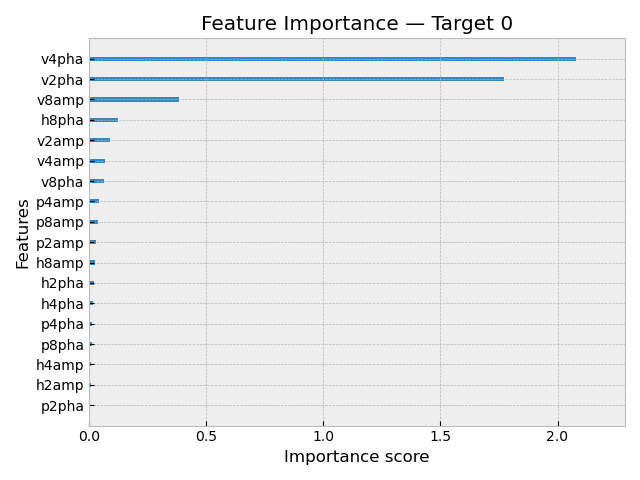

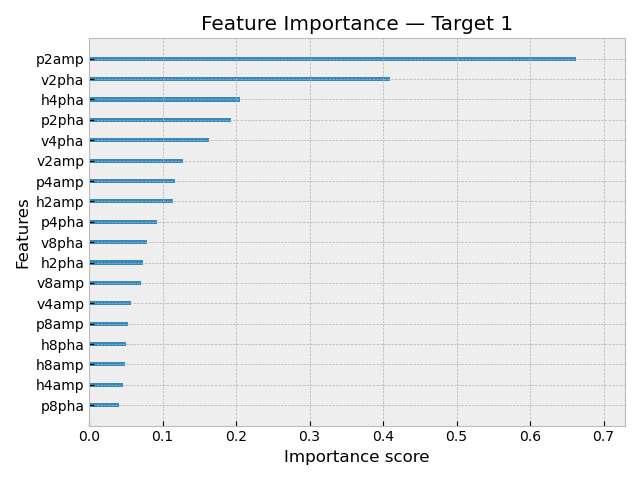

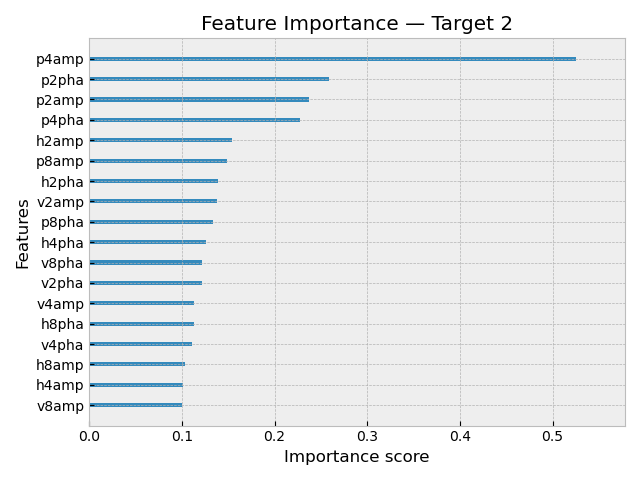

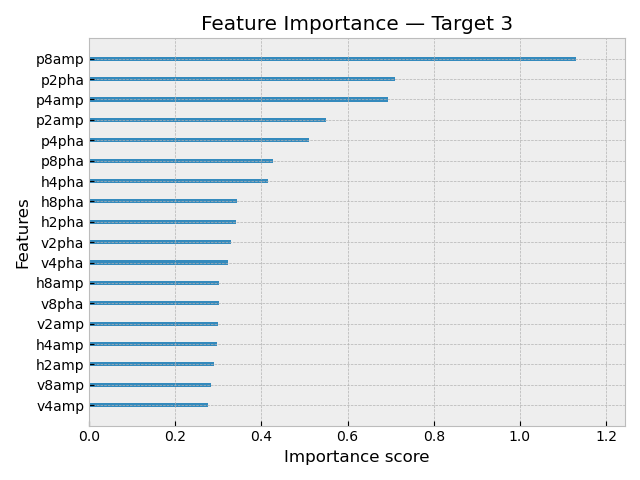

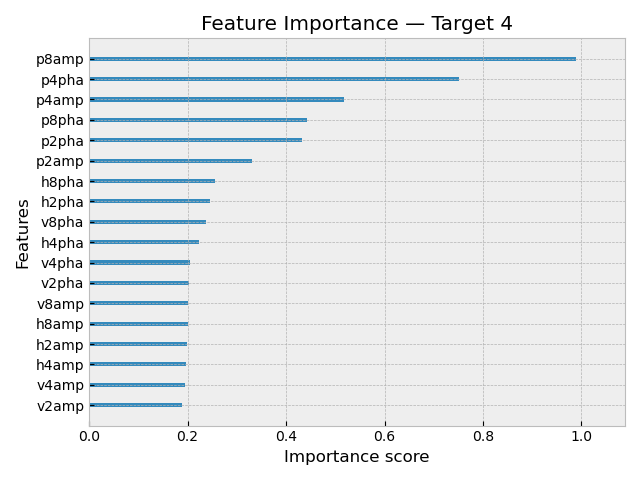

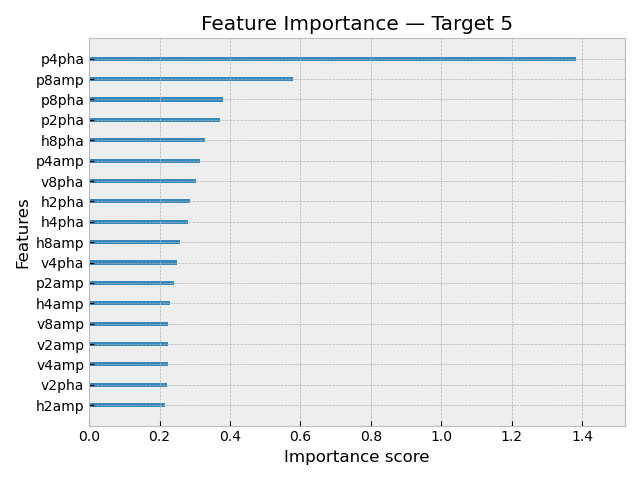

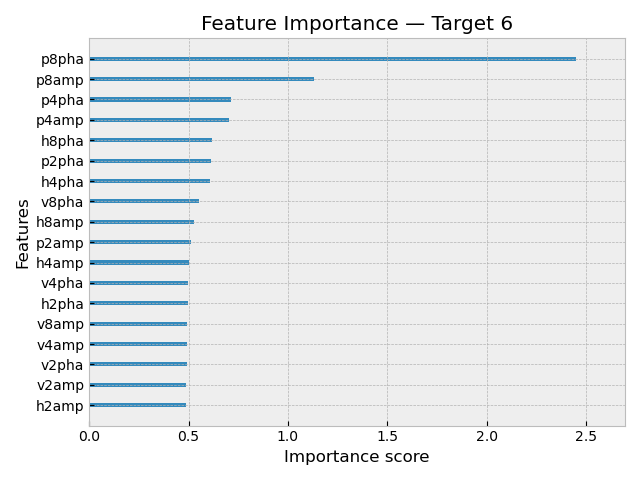

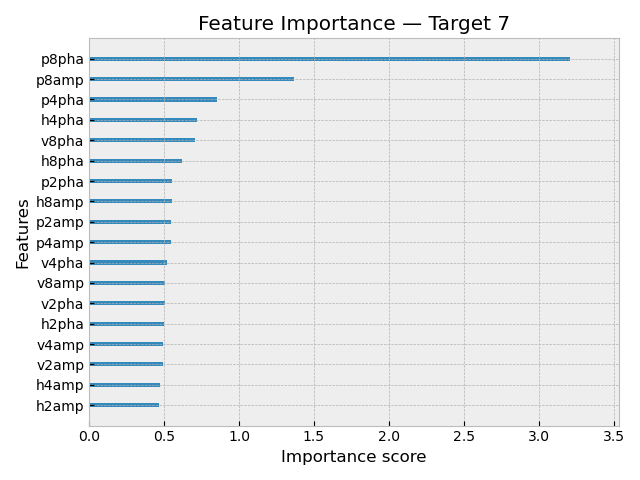

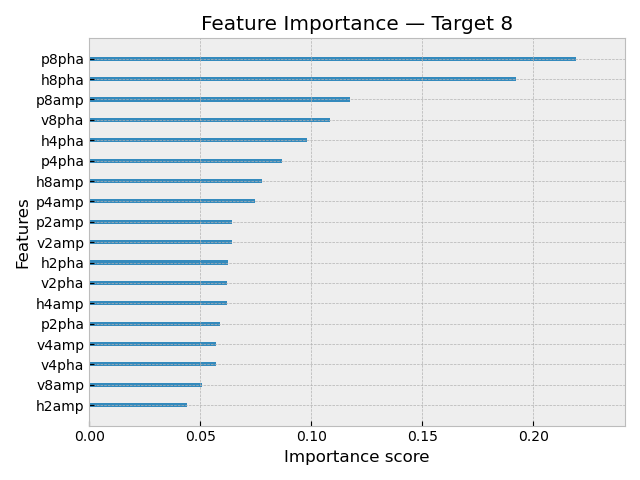

In [18]:
#for i, estimator in enumerate(best_model.estimators_):
#    booster = estimator.get_booster()
#    booster.feature_names = features

features = Data_X.columns.tolist()

# Feature importance per output
for i, model in enumerate(best_models):
    #print(f"\nFeature importance for output {i}:")
    booster = model.get_booster()
    booster.feature_names = features
    importances = model.feature_importances_
    
  #  plt.figure(figsize=(10, 6))
    plot_importance(booster, importance_type='gain', show_values=False)
    plt.title(f"Feature Importance — Target {i}")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3232052/600892164.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3,3, figsize=(9,6))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


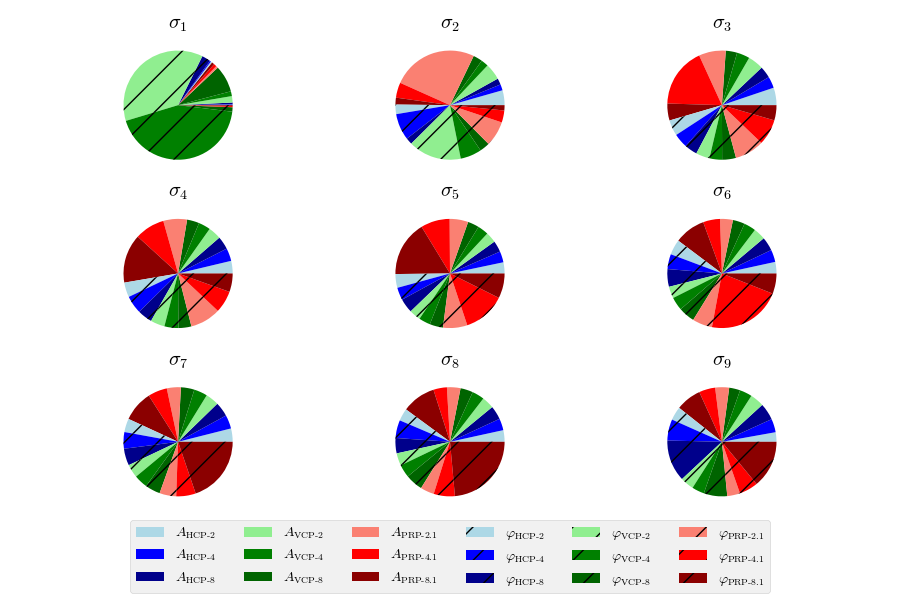

In [93]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3,3, figsize=(9,6))

ax = axes.ravel()

for i, model in enumerate(best_models):
    booster = model.get_booster()
    keys = [r'$A_{\text{HCP-2}}$', r'$A_{\text{HCP-4}}$', r'$A_{\text{HCP-8}}$', r'$A_{\text{VCP-2}}$', r'$A_{\text{VCP-4}}$', r'$A_{\text{VCP-8}}$',
            r'$A_{\text{PRP-2.1}}$', r'$A_{\text{PRP-4.1}}$', r'$A_{\text{PRP-8.1}}$', r'$\varphi_{\text{HCP-2}}$', r'$\varphi_{\text{HCP-4}}$', r'$\varphi_{\text{HCP-8}}$', 
            r'$\varphi_{\text{VCP-2}}$', r'$\varphi_{\text{VCP-4}}$', r'$\varphi_{\text{VCP-8}}$', r'$\varphi_{\text{PRP-2.1}}$',
            r'$\varphi_{\text{PRP-4.1}}$', r'$\varphi_{\text{PRP-8.1}}$']
    impo = booster.get_score(importance_type='gain').values()
    colors = ['lightblue', 'blue', 'darkblue', 'lightgreen', 'green', 'darkgreen', 'salmon', 'red', 'darkred',
             'lightblue', 'blue', 'darkblue', 'lightgreen', 'green', 'darkgreen', 'salmon', 'red', 'darkred',]
    hatch = ['', '', '', '', '', '', '', '', '', '/', '/', '/', '/', '/', '/', '/', '/', '/'] 
    ax[i].pie(impo, colors=colors, hatch=hatch, textprops={'size': 'smaller'})
    ax[i].set_title(f'$\sigma_{i+1}$')

# --- Create proxy handles for legend ---
patches = [
    mpatches.Patch(facecolor=c, hatch=h, label=k) 
    for c, h, k in zip(colors, hatch, keys)
]

# Place the legend below all subplots
fig.legend(
    handles=patches, loc='lower center', ncol=6,
    bbox_to_anchor=(0.5, -0.0)  # adjust vertical position
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # make space for legend
plt.savefig('FeatureImportance.eps', format='eps')
plt.show()

In [19]:
booster.get_score(importance_type='gain').keys()

dict_keys(['h2amp', 'h4amp', 'h8amp', 'v2amp', 'v4amp', 'v8amp', 'p2amp', 'p4amp', 'p8amp', 'h2pha', 'h4pha', 'h8pha', 'v2pha', 'v4pha', 'v8pha', 'p2pha', 'p4pha', 'p8pha'])

In [20]:
#y_pred = best_model.predict(X_test)
y_pred = np.column_stack([model.predict(X_test) for model in best_models])

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming y_true and y_pred are your true and predicted values
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")
# These metrics can help you understand how well your XGBRegressor model is performing and where it might need improvement.



MAE: 0.147529259727923
MSE: 0.03898206575991665
RMSE: 0.19743876458263368
R²: 0.5314664785986608


In [22]:
y_test_sigmas = 10**scale_y.inverse_transform(y_test)
y_pred_sigmas = 10**scale_y.inverse_transform(y_pred)

In [23]:
y_test_sigmas

array([[0.30549734, 0.21339387, 0.11235869, ..., 0.00130151, 0.00131268,
        0.00491027],
       [0.86000883, 0.96734894, 0.8042388 , ..., 0.00118234, 0.03808607,
        0.01933613],
       [0.00149353, 0.2807918 , 0.49251548, ..., 0.00124895, 0.0245841 ,
        0.00788146],
       ...,
       [0.29528758, 0.1875862 , 0.07950116, ..., 0.74143101, 0.04082909,
        0.00536549],
       [0.00437357, 0.05930507, 0.00254961, ..., 0.00687673, 0.00749023,
        0.02729947],
       [0.29953188, 0.00200721, 0.0498563 , ..., 0.2333812 , 0.01974931,
        0.98415526]])

In [24]:
y_pred_sigmas

array([[0.3073371 , 0.22856691, 0.02300755, ..., 0.00704434, 0.00669087,
        0.00340485],
       [0.8558564 , 0.7308037 , 0.7330961 , ..., 0.04507739, 0.04232508,
        0.02871276],
       [0.00144893, 0.2647235 , 0.44579348, ..., 0.01059318, 0.00781744,
        0.00389169],
       ...,
       [0.29749465, 0.09833958, 0.15218651, ..., 0.04553473, 0.05021274,
        0.03595791],
       [0.0045891 , 0.04134845, 0.01646337, ..., 0.01216373, 0.01310399,
        0.00957189],
       [0.29789865, 0.00620714, 0.02392204, ..., 0.02478478, 0.30198896,
        0.7127262 ]], dtype=float32)

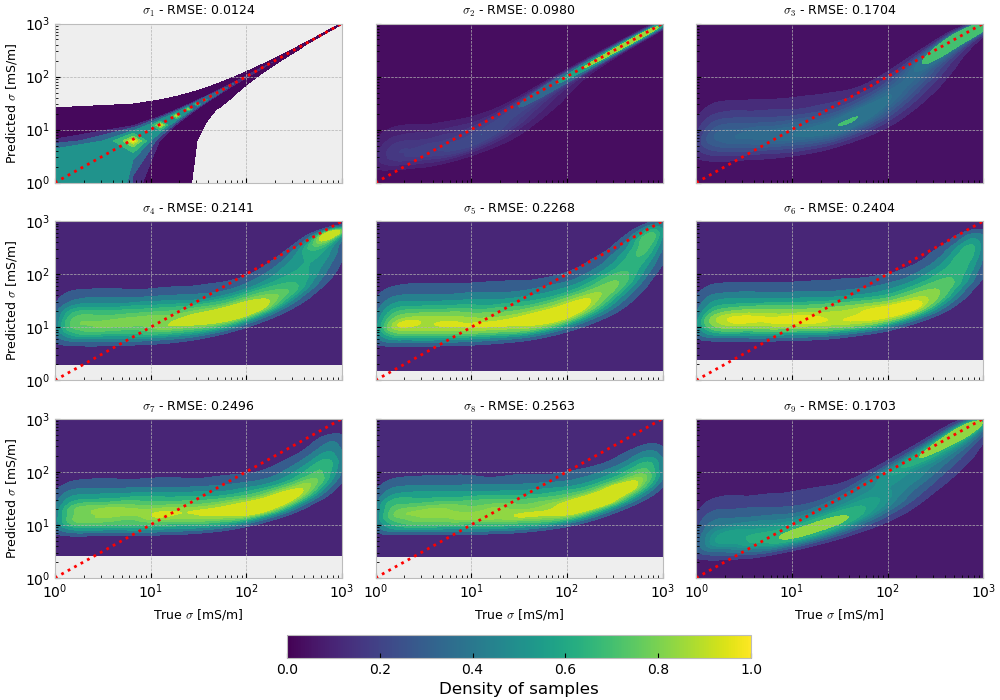

In [100]:
fig, ax = plt.subplots(3, 3, figsize = (10,7), sharex=True, sharey=True, constrained_layout=True)

axes = ax.flatten()

import seaborn as sns

for i in range(len(axes)):
    # Plot using kdeplot
  #
    sns.kdeplot(x=y_test_sigmas[:,i]*1000, y=y_pred_sigmas[:,i]*1000, fill=True, cmap='viridis', thresh=0, levels=np.linspace(0,1,10), ax=axes[i])
    #c = axes[i].scatter(y11, y22, c=z) #, s=.1) #cmap='viridis')
    axes[i].plot([1,1500], [1,1500], ':r')
    axes[i].set_ylim([1, 1000])
    axes[i].set_xlim([1, 1000])
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    rmse = root_mean_squared_error(y_test[:,i], y_pred[:,i])
    axes[i].set_title(f'$\sigma_{i+1}$ - RMSE: {rmse:.4f}', fontsize=9)

axes[0].set_ylabel('Predicted $\sigma$ [mS/m]', fontsize=9)
axes[3].set_ylabel('Predicted $\sigma$ [mS/m]', fontsize=9)
axes[6].set_ylabel('Predicted $\sigma$ [mS/m]', fontsize=9)
axes[6].set_xlabel('True $\sigma$ [mS/m]', fontsize=9)
axes[7].set_xlabel('True $\sigma$ [mS/m]', fontsize=9)
axes[8].set_xlabel('True $\sigma$ [mS/m]', fontsize=9)

from matplotlib.cm import ScalarMappable
sm = ScalarMappable(cmap="viridis")
fig.colorbar(sm, orientation="horizontal", ax= ax, pad=0.02, location='bottom', shrink=.5, label='Density of samples')

#plt.tight_layout()
plt.savefig('DensityPlot.eps', format='eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


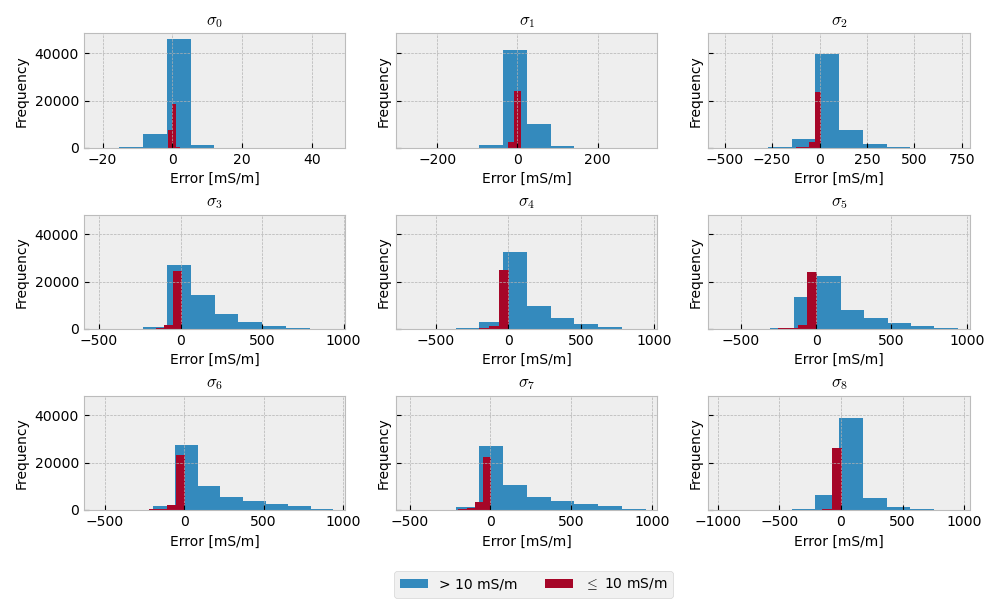

In [29]:
# Plot histograms

fig, axs = plt.subplots(3,3,figsize=(10,6),  sharey=True, )

ax = axs.ravel()

for s in range(9):
    error_above = []
    error_below = []
    for i in range(len(y_test_sigmas)):
        if y_test_sigmas[i,s] > 10/1000:
            error_above.append((y_test_sigmas[i,s] - y_pred_sigmas[i,s])*1000)
        else:
            error_below.append((y_test_sigmas[i,s] - y_pred_sigmas[i,s])*1000)
    error_above = np.array(error_above)
    error_below = np.array(error_below)
    error_above = error_above[error_above > -1000]
    error_below = error_below[error_below > -1000]
    ax[s].hist(error_above.ravel(), label= '> 10 mS/m')
    ax[s].hist(error_below.ravel(), label= '$\leq$ 10 mS/m')
    ax[s].set_title(f'$\sigma_{s}$', fontsize=12)
    ax[s].set_ylabel('Frequency', fontsize=10)
    ax[s].set_xlabel('Error [mS/m]', fontsize=10)

fig.legend(['> 10 mS/m', '$\leq$ 10 mS/m'], ncol=2,
    bbox_to_anchor=(0.68, 0.06) )
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # make space for legend
plt.savefig('Histogram_.eps', format='eps')
plt.show()


In [28]:
# Save model
#joblib.dump(best_model, 'best_xgb_model_300est_maxdep13_30it_40cv_9Layers_new.pkl')

# Test CNN on data from Training

In [105]:
# Choose 10 random models
np.random.seed(10)

idx = np.linspace(0, len(y_train), len(y_train), endpoint=False, dtype=int)

random_idx = np.random.choice(idx, size = 10, )
random_models = y_train[random_idx]
random_data = X_train[random_idx]

In [106]:
# Predict models
#random_models_pred_norm = best_model.predict(random_data)
random_models_pred_norm = np.column_stack([model.predict(random_data) for model in best_models])
random_models_pred = 10**scale_y.inverse_transform(random_models_pred_norm)

In [107]:
# Data fit

random_data_ = np.array(scale_X.inverse_transform(random_data))

In [108]:
random_data_pred =[]

for m in random_models_pred:
    random_data_pred.append(FDEM(m, h1))

random_data_pred = np.array(random_data_pred)
print('Done!')



Done!


In [35]:
def OPIPtoAmpPha(data_op, data_ip):
    data_complex = data_op + 1j*data_ip
    data_Amp = np.abs(data_complex)
    data_Pha = np.angle(data_complex)
    return np.log10(data_Amp), data_Pha

def AmpPhatoOPIP(data_logAmp, data_Pha):
    # Convert to real and imaginary components
    data_op = (10**data_logAmp) * np.cos(data_Pha)
    data_ip = (10**data_logAmp) * np.sin(data_Pha)
    return data_op, data_ip

In [110]:
# random_data_  -> logAmp h2, logAmp h4, logAmp h8, logAmp v2, logAmp v4, logAmp v8, logAmp p2, logAmp p4, logAmp p8,
#                  pha h2, pha h4, pha h8, pha v2, pha v4, pha v8, pha p2, pha p4, pha p8

# random_data_pred -> h2op, h4op, h8op, h2ip, h4ip, h8ip, 
#                     v2op, v4op, v8op, v2ip, v4ip, v8ip, 
#                     p2op, p4op, p8op, p2ip, p4ip, p8ip

random_data_pred_AmpPha = np.zeros_like(random_data_pred)

random_data_pred_AmpPha[:,0], random_data_pred_AmpPha[:,9] = OPIPtoAmpPha(random_data_pred[:,0], random_data_pred[:,3]) # h2
random_data_pred_AmpPha[:,1], random_data_pred_AmpPha[:,10] = OPIPtoAmpPha(random_data_pred[:,1], random_data_pred[:,4]) # h4
random_data_pred_AmpPha[:,2], random_data_pred_AmpPha[:,11] = OPIPtoAmpPha(random_data_pred[:,2], random_data_pred[:,5]) # h8

random_data_pred_AmpPha[:,3], random_data_pred_AmpPha[:,12] = OPIPtoAmpPha(random_data_pred[:,6], random_data_pred[:,9]) # v2
random_data_pred_AmpPha[:,4], random_data_pred_AmpPha[:,13] = OPIPtoAmpPha(random_data_pred[:,7], random_data_pred[:,10]) # v4
random_data_pred_AmpPha[:,5], random_data_pred_AmpPha[:,14] = OPIPtoAmpPha(random_data_pred[:,8], random_data_pred[:,11]) # v8

random_data_pred_AmpPha[:,6], random_data_pred_AmpPha[:,15] = OPIPtoAmpPha(random_data_pred[:,12], random_data_pred[:,15]) # v2
random_data_pred_AmpPha[:,7], random_data_pred_AmpPha[:,16] = OPIPtoAmpPha(random_data_pred[:,13], random_data_pred[:,16]) # v4
random_data_pred_AmpPha[:,8], random_data_pred_AmpPha[:,17] = OPIPtoAmpPha(random_data_pred[:,14], random_data_pred[:,17]) # v8

random_data_OPIP = np.zeros_like(random_data_)

random_data_OPIP[:,0], random_data_OPIP[:,3] = AmpPhatoOPIP(random_data_[:,0], random_data_[:,9]) # h2
random_data_OPIP[:,1], random_data_OPIP[:,4] = AmpPhatoOPIP(random_data_[:,1], random_data_[:,10]) # h4
random_data_OPIP[:,2], random_data_OPIP[:,5] = AmpPhatoOPIP(random_data_[:,2], random_data_[:,11]) # h8

random_data_OPIP[:,6], random_data_OPIP[:,9] = AmpPhatoOPIP(random_data_[:,3], random_data_[:,12]) # v2
random_data_OPIP[:,7], random_data_OPIP[:,10] = AmpPhatoOPIP(random_data_[:,4], random_data_[:,13]) # v4
random_data_OPIP[:,8], random_data_OPIP[:,11] = AmpPhatoOPIP(random_data_[:,5], random_data_[:,14]) # v8

random_data_OPIP[:,12], random_data_OPIP[:,15] = AmpPhatoOPIP(random_data_[:,6], random_data_[:,15]) # p2
random_data_OPIP[:,13], random_data_OPIP[:,16] = AmpPhatoOPIP(random_data_[:,7], random_data_[:,16]) # p4
random_data_OPIP[:,14], random_data_OPIP[:,17] = AmpPhatoOPIP(random_data_[:,8], random_data_[:,17]) # p8

In [111]:
# Create a data pred norm dataframe

random_data_pred_AmpPha_ = pd.DataFrame(random_data_pred_AmpPha,
                                     columns = ['h2amp', 'h4amp', 'h8amp', 'v2amp', 'v4amp', 'v8amp', 'p2amp', 'p4amp', 'p8amp',
                                                'h2pha', 'h4pha', 'h8pha', 'v2pha', 'v4pha', 'v8pha', 'p2pha', 'p4pha', 'p8pha',])

random_data_pred_norm = scale_X.transform(random_data_pred_AmpPha_)



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


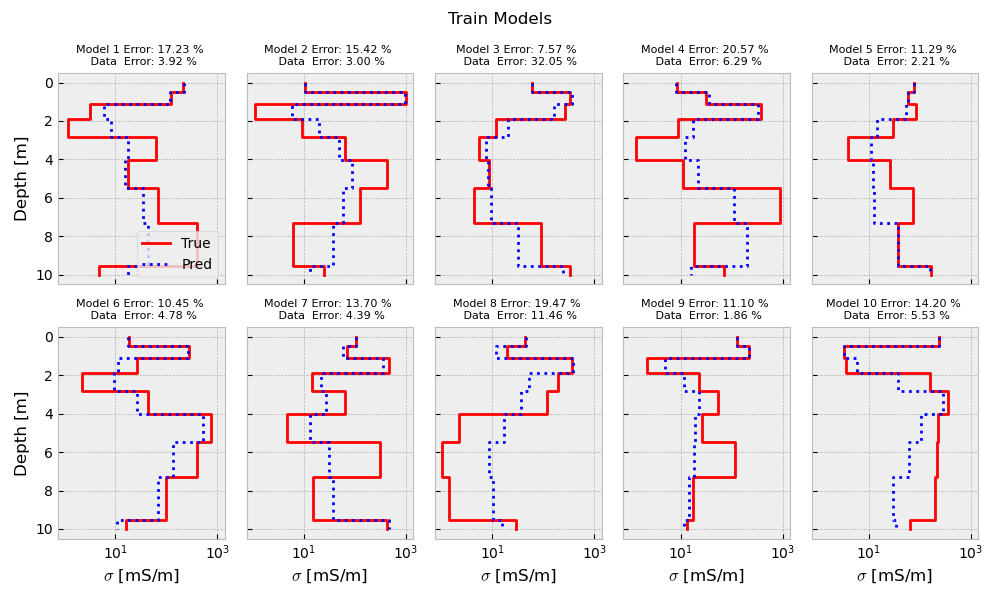

In [112]:
fig, ax = plt.subplots(2, 5, figsize=(10,6), sharey=True, sharex=True)

axes = ax.flatten()

random_models_ = 10**np.array(scale_y.inverse_transform(random_models))

for i in range(len(axes)):
    axes[i].step(np.hstack((1000*random_models_[i], [1000*random_models_[i,-1]])),
                 np.hstack(([0], np.cumsum(h1), [10])), 'r')
    axes[i].step(np.hstack((1000*random_models_pred[i], [1000*random_models_pred[i,-1]])),
                 np.hstack(([0], np.cumsum(h1), [10])), ':b')
    # rmspe = np.sqrt(np.mean(((predicted - actual) / actual) ** 2)) * 100
    rmse = 100 * np.sqrt(np.mean(((random_models_pred_norm[i]-random_models[i]))**2))
    d_rmse =  100 * np.sqrt(np.mean(((random_data_pred_norm[i]-random_data[i]))**2))
    axes[i].set_title('Model ' + str(i+1) + f' Error: {rmse:.2f} %' + ' \n Data ' + f' Error: {d_rmse:.2f} %' , fontsize=8)
    
    if i > 4:
        axes[i].set_xlabel('$\sigma$ [mS/m]')
axes[0].legend(['True', 'Pred'])
axes[-1].invert_yaxis()
axes[-1].set_xscale('log')
axes[0].set_ylabel('Depth [m]')
axes[5].set_ylabel('Depth [m]')

fig.suptitle('Train Models')
plt.tight_layout()
plt.savefig('Train Models.eps', format='eps')

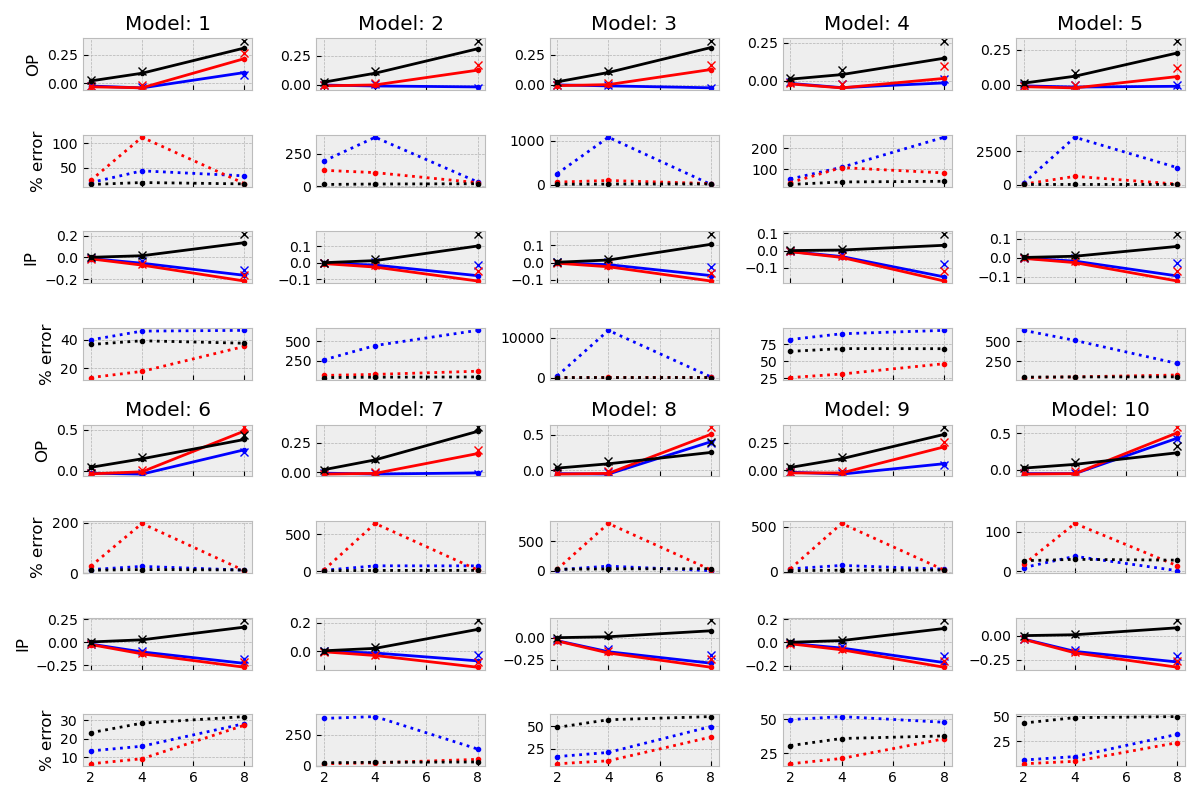

In [55]:
fig, ax = plt.subplots(8,5, figsize=(12,8), sharex=True, )

for i in range(5):
    ax[0,i].plot([2,4,8], random_data_pred[i,:3], '-b.') # hop
    ax[0,i].plot([2,4,8], random_data_OPIP[i,:3], 'xb')
    ax[0,i].plot([2,4,8], random_data_pred[i,6:9], '-r.') # vop
    ax[0,i].plot([2,4,8], random_data_OPIP[i,6:9], 'xr')
    ax[0,i].plot([2,4,8], random_data_pred[i,12:15], '-k.') # pop
    ax[0,i].plot([2,4,8], random_data_OPIP[i,12:15], 'xk')
   
  #  rmse = 100* np.sqrt(np.mean(((random_data_pred[i]-random_data_OPIP[i])/random_data_OPIP[i])**2))
    ax[0,i].set_title('Model: ' + str(i+1) ) #+ f' - % error: {rmse:.4f}', fontsize=8)

    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,:3]-random_data_OPIP[i,:3])/random_data_OPIP[i,:3])**2), '.:b')
    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,6:9]-random_data_OPIP[i,6:9])/random_data_OPIP[i,6:9])**2), '.:r')
    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,12:15]-random_data_OPIP[i,12:15])/random_data_OPIP[i,12:15])**2), '.:k')

    ax[2,i].plot([2,4,8], random_data_pred[i,3:6], '-b.') # hip
    ax[2,i].plot([2,4,8], random_data_OPIP[i,3:6], 'xb')
    ax[2,i].plot([2,4,8], random_data_pred[i,9:12], '-r.') # vip
    ax[2,i].plot([2,4,8], random_data_OPIP[i,9:12], 'xr')
    ax[2,i].plot([2,4,8], random_data_pred[i,15:], '-k.') # pip
    ax[2,i].plot([2,4,8], random_data_OPIP[i,15:], 'xk')

    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,3:6]-random_data_OPIP[i,3:6])/random_data_OPIP[i,3:6])**2), '.:b')
    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,9:12]-random_data_OPIP[i,9:12])/random_data_OPIP[i,9:12])**2), '.:r')
    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,15:]-random_data_OPIP[i,15:])/random_data_OPIP[i,15:])**2), '.:k')

    ax[4,i].plot([2,4,8], random_data_pred[i+5,:3], '-b.') # hop
    ax[4,i].plot([2,4,8], random_data_OPIP[i+5,:3], 'xb')
    ax[4,i].plot([2,4,8], random_data_pred[i+5,6:9], '-r.') # vop
    ax[4,i].plot([2,4,8], random_data_OPIP[i+5,6:9], 'xr')
    ax[4,i].plot([2,4,8], random_data_pred[i+5,12:15], '-k.') # pop
    ax[4,i].plot([2,4,8], random_data_OPIP[i+5,12:15], 'xk')
#    rmse = 100* np.sqrt(np.mean(((random_data_pred[i]-random_data_OPIP[i])/random_data_OPIP[i])**2))
    ax[4,i].set_title('Model: ' + str(i+6) ) # + f' - % error: {rmse:.4f}', fontsize=8)

    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,:3]-random_data_OPIP[i+5,:3])/random_data_OPIP[i+5,:3])**2), '.:b')
    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,6:9]-random_data_OPIP[i+5,6:9])/random_data_OPIP[i+5,6:9])**2), '.:r')
    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,12:15]-random_data_OPIP[i+5,12:15])/random_data_OPIP[i+5,12:15])**2), '.:k')

    ax[6,i].plot([2,4,8], random_data_pred[i+5,3:6], '-b.') # hip
    ax[6,i].plot([2,4,8], random_data_OPIP[i+5,3:6], 'xb')
    ax[6,i].plot([2,4,8], random_data_pred[i+5,9:12], '-r.') # vip
    ax[6,i].plot([2,4,8], random_data_OPIP[i+5,9:12], 'xr')
    ax[6,i].plot([2,4,8], random_data_pred[i+5,15:], '-k.') # pip
    ax[6,i].plot([2,4,8], random_data_OPIP[i+5,15:], 'xk')

    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,3:6]-random_data_OPIP[i+5,3:6])/random_data_OPIP[i+5,3:6])**2), '.:b')
    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,9:12]-random_data_OPIP[i+5,9:12])/random_data_OPIP[i+5,9:12])**2), '.:r')
    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,15:]-random_data_OPIP[i+5,15:])/random_data_OPIP[i+5,15:])**2), '.:k')

ax[0,0].set_ylabel('OP')
ax[1,0].set_ylabel('% error')
ax[2,0].set_ylabel('IP')
ax[3,0].set_ylabel('% error')

ax[4,0].set_ylabel('OP')
ax[5,0].set_ylabel('% error')
ax[6,0].set_ylabel('IP')
ax[7,0].set_ylabel('% error')

plt.tight_layout()

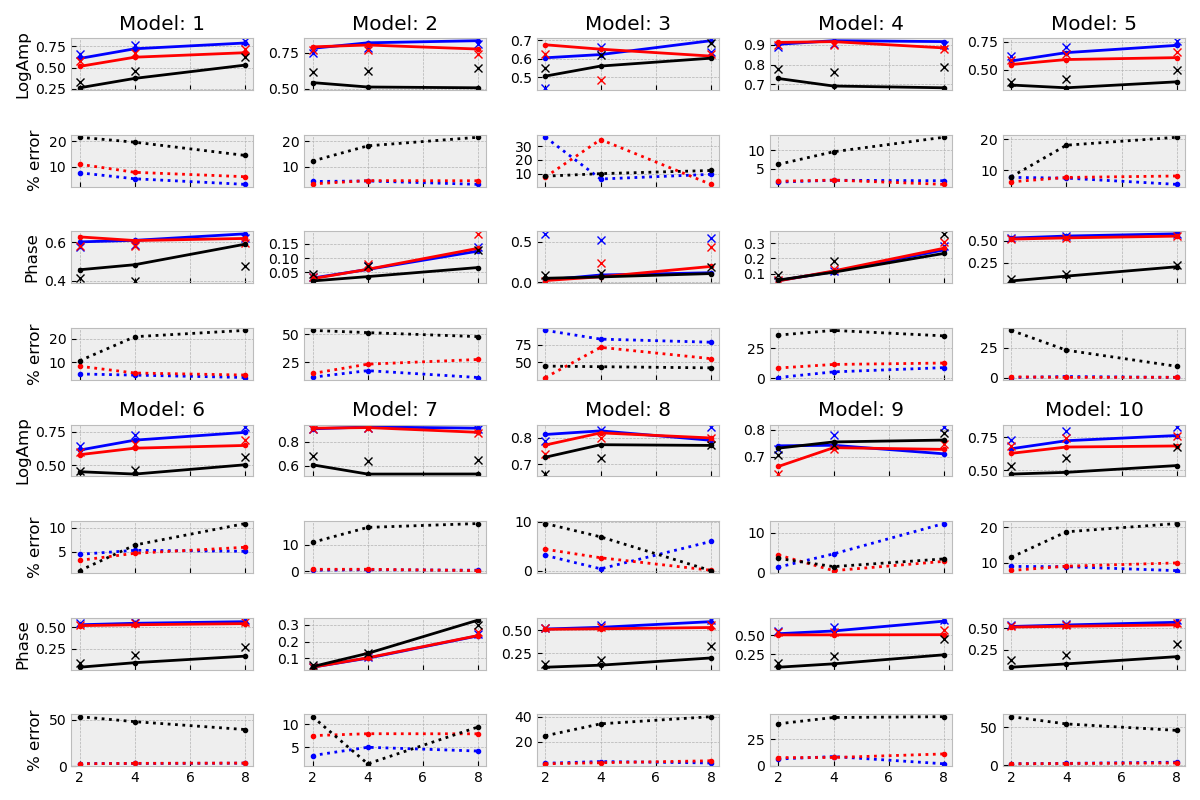

In [263]:
fig, ax = plt.subplots(8,5, figsize=(12,8), sharex=True, )

for i in range(5):
    ax[0,i].plot([2,4,8], random_data_pred_norm[i,:3], '-b.') # hAmp
    ax[0,i].plot([2,4,8], random_data[i,:3], 'xb')
    ax[0,i].plot([2,4,8], random_data_pred_norm[i,3:6], '-r.') # vAmp
    ax[0,i].plot([2,4,8], random_data[i,3:6], 'xr')
    ax[0,i].plot([2,4,8], random_data_pred_norm[i,6:9], '-k.') # pAmp
    ax[0,i].plot([2,4,8], random_data[i,6:9], 'xk')
   
  #  rmse = 100* np.sqrt(np.mean(((random_data_pred[i]-random_data_OPIP[i])/random_data_OPIP[i])**2))
    ax[0,i].set_title('Model: ' + str(i+1) ) #+ f' - % error: {rmse:.4f}', fontsize=8)

    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,:3]-random_data[i,:3])/random_data[i,:3])**2), '.:b')
    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,3:6]-random_data[i,3:6])/random_data[i,3:6])**2), '.:r')
    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,6:9]-random_data[i,6:9])/random_data[i,6:9])**2), '.:k')

    ax[2,i].plot([2,4,8], random_data_pred_norm[i,9:12], '-b.') # hPha
    ax[2,i].plot([2,4,8], random_data[i,9:12], 'xb')
    ax[2,i].plot([2,4,8], random_data_pred_norm[i,12:15], '-r.') # vPha
    ax[2,i].plot([2,4,8], random_data[i,12:15], 'xr')
    ax[2,i].plot([2,4,8], random_data_pred_norm[i,15:], '-k.') # pPha
    ax[2,i].plot([2,4,8], random_data[i,15:], 'xk')

    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,9:12]-random_data[i,9:12])/random_data[i,9:12])**2), '.:b')
    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,12:15]-random_data[i,12:15])/random_data[i,12:15])**2), '.:r')
    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,15:]-random_data[i,15:])/random_data[i,15:])**2), '.:k')

    ax[4,i].plot([2,4,8], random_data_pred_norm[i+5,:3], '-b.') # hAmp
    ax[4,i].plot([2,4,8], random_data[i+5,:3], 'xb')
    ax[4,i].plot([2,4,8], random_data_pred_norm[i+5,3:6], '-r.') # vAmp
    ax[4,i].plot([2,4,8], random_data[i+5,3:6], 'xr')
    ax[4,i].plot([2,4,8], random_data_pred_norm[i+5,6:9], '-k.') # pAmp
    ax[4,i].plot([2,4,8], random_data[i+5,6:9], 'xk')
#    rmse = 100* np.sqrt(np.mean(((random_data_pred[i]-random_data_OPIP[i])/random_data_OPIP[i])**2))
    ax[4,i].set_title('Model: ' + str(i+6) ) # + f' - % error: {rmse:.4f}', fontsize=8)

    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,:3]-random_data[i+5,:3])/random_data[i+5,:3])**2), '.:b')
    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,3:6]-random_data[i+5,3:6])/random_data[i+5,3:6])**2), '.:r')
    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,6:9]-random_data[i+5,6:9])/random_data[i+5,6:9])**2), '.:k')

    ax[6,i].plot([2,4,8], random_data_pred_norm[i+5,9:12], '-b.') # hPha
    ax[6,i].plot([2,4,8], random_data[i+5,9:12], 'xb')
    ax[6,i].plot([2,4,8], random_data_pred_norm[i+5,12:15], '-r.') # vPha
    ax[6,i].plot([2,4,8], random_data[i+5,12:15], 'xr')
    ax[6,i].plot([2,4,8], random_data_pred_norm[i+5,15:], '-k.') # pPha
    ax[6,i].plot([2,4,8], random_data[i+5,15:], 'xk')

    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,9:12]-random_data[i+5,9:12])/random_data[i+5,9:12])**2), '.:b')
    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,12:15]-random_data[i+5,12:15])/random_data[i+5,12:15])**2), '.:r')
    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,15:]-random_data[i+5,15:])/random_data[i+5,15:])**2), '.:k')

ax[0,0].set_ylabel('LogAmp')
ax[1,0].set_ylabel('% error')
ax[2,0].set_ylabel('Phase')
ax[3,0].set_ylabel('% error')

ax[4,0].set_ylabel('LogAmp')
ax[5,0].set_ylabel('% error')
ax[6,0].set_ylabel('Phase')
ax[7,0].set_ylabel('% error')

#ax[0,4].legend(['H true', 'H pred', 'V true', 'V pred', 'P true', 'P pred'], loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

In [264]:
# Save the best model to a file
#joblib.dump(best_model, 'best_xgb_model_large.pkl')

# Test CNN on data from Testing

In [113]:
# Choose 10 random models
np.random.seed(10)

idx = np.linspace(0, len(y_test), len(y_test), endpoint=False, dtype=int)

random_idx = np.random.choice(idx, size = 10, )
random_models = y_test[random_idx]
random_data = X_test[random_idx]

In [114]:
# Predict models
#random_models_pred_norm = best_model.predict(random_data)
random_models_pred_norm = np.column_stack([model.predict(random_data) for model in best_models])
random_models_pred = 10**scale_y.inverse_transform(random_models_pred_norm)

In [115]:
# Data fit

random_data_ = np.array(scale_X.inverse_transform(random_data))

random_data_pred =[]

for m in random_models_pred:
    random_data_pred.append(FDEM(m, h1))

random_data_pred = np.array(random_data_pred)
#print('Done!')

random_data_pred_AmpPha = np.zeros_like(random_data_pred)

random_data_pred_AmpPha[:,0], random_data_pred_AmpPha[:,9] = OPIPtoAmpPha(random_data_pred[:,0], random_data_pred[:,3]) # h2
random_data_pred_AmpPha[:,1], random_data_pred_AmpPha[:,10] = OPIPtoAmpPha(random_data_pred[:,1], random_data_pred[:,4]) # h4
random_data_pred_AmpPha[:,2], random_data_pred_AmpPha[:,11] = OPIPtoAmpPha(random_data_pred[:,2], random_data_pred[:,5]) # h8

random_data_pred_AmpPha[:,3], random_data_pred_AmpPha[:,12] = OPIPtoAmpPha(random_data_pred[:,6], random_data_pred[:,9]) # v2
random_data_pred_AmpPha[:,4], random_data_pred_AmpPha[:,13] = OPIPtoAmpPha(random_data_pred[:,7], random_data_pred[:,10]) # v4
random_data_pred_AmpPha[:,5], random_data_pred_AmpPha[:,14] = OPIPtoAmpPha(random_data_pred[:,8], random_data_pred[:,11]) # v8

random_data_pred_AmpPha[:,6], random_data_pred_AmpPha[:,15] = OPIPtoAmpPha(random_data_pred[:,12], random_data_pred[:,15]) # v2
random_data_pred_AmpPha[:,7], random_data_pred_AmpPha[:,16] = OPIPtoAmpPha(random_data_pred[:,13], random_data_pred[:,16]) # v4
random_data_pred_AmpPha[:,8], random_data_pred_AmpPha[:,17] = OPIPtoAmpPha(random_data_pred[:,14], random_data_pred[:,17]) # v8

random_data_OPIP = np.zeros_like(random_data_)

random_data_OPIP[:,0], random_data_OPIP[:,3] = AmpPhatoOPIP(random_data_[:,0], random_data_[:,9]) # h2
random_data_OPIP[:,1], random_data_OPIP[:,4] = AmpPhatoOPIP(random_data_[:,1], random_data_[:,10]) # h4
random_data_OPIP[:,2], random_data_OPIP[:,5] = AmpPhatoOPIP(random_data_[:,2], random_data_[:,11]) # h8

random_data_OPIP[:,6], random_data_OPIP[:,9] = AmpPhatoOPIP(random_data_[:,3], random_data_[:,12]) # v2
random_data_OPIP[:,7], random_data_OPIP[:,10] = AmpPhatoOPIP(random_data_[:,4], random_data_[:,13]) # v4
random_data_OPIP[:,8], random_data_OPIP[:,11] = AmpPhatoOPIP(random_data_[:,5], random_data_[:,14]) # v8

random_data_OPIP[:,12], random_data_OPIP[:,15] = AmpPhatoOPIP(random_data_[:,6], random_data_[:,15]) # p2
random_data_OPIP[:,13], random_data_OPIP[:,16] = AmpPhatoOPIP(random_data_[:,7], random_data_[:,16]) # p4
random_data_OPIP[:,14], random_data_OPIP[:,17] = AmpPhatoOPIP(random_data_[:,8], random_data_[:,17]) # p8

# Create a data pred norm dataframe

random_data_pred_AmpPha_ = pd.DataFrame(random_data_pred_AmpPha,
                                     columns = ['h2amp', 'h4amp', 'h8amp', 'v2amp', 'v4amp', 'v8amp', 'p2amp', 'p4amp', 'p8amp',
                                                'h2pha', 'h4pha', 'h8pha', 'v2pha', 'v4pha', 'v8pha', 'p2pha', 'p4pha', 'p8pha',])

random_data_pred_norm = scale_X.transform(random_data_pred_AmpPha_)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


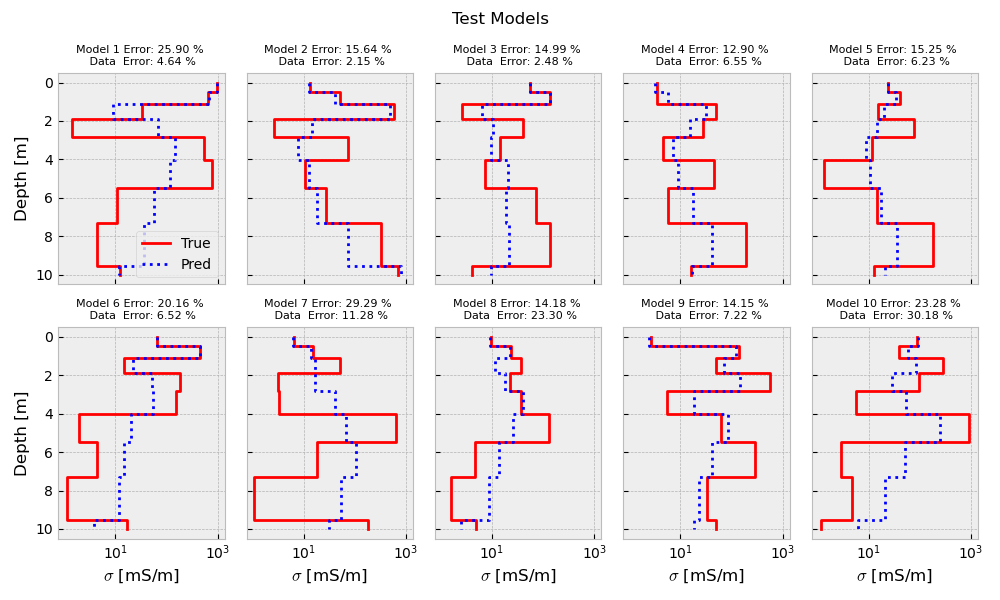

In [116]:
fig, ax = plt.subplots(2, 5, figsize=(10,6), sharey=True, sharex=True)

axes = ax.flatten()

random_models_ = 10**np.array(scale_y.inverse_transform(random_models))

for i in range(len(axes)):
    axes[i].step(np.hstack((1000*random_models_[i], [1000*random_models_[i,-1]])),
                 np.hstack(([0], np.cumsum(h1), [10])), 'r')
    axes[i].step(np.hstack((1000*random_models_pred[i], [1000*random_models_pred[i,-1]])),
                 np.hstack(([0], np.cumsum(h1), [10])), ':b')
    # rmspe = np.sqrt(np.mean(((predicted - actual) / actual) ** 2)) * 100
    rmse = 100*np.sqrt(np.mean(((random_models_pred_norm[i]-random_models[i]))**2))
    d_rmse = 100*np.sqrt(np.mean(((random_data_pred_norm[i]-random_data[i]))**2))
    axes[i].set_title('Model ' + str(i+1) + f' Error: {rmse:.2f} %' + ' \n Data ' + f' Error: {d_rmse:.2f} %' , fontsize=8)
    
    if i > 4:
        axes[i].set_xlabel('$\sigma$ [mS/m]')
axes[0].legend(['True', 'Pred'])
axes[-1].invert_yaxis()
axes[-1].set_xscale('log')
axes[0].set_ylabel('Depth [m]')
axes[5].set_ylabel('Depth [m]')

fig.suptitle('Test Models')
plt.tight_layout()
plt.savefig('TestModels.eps', format='eps')

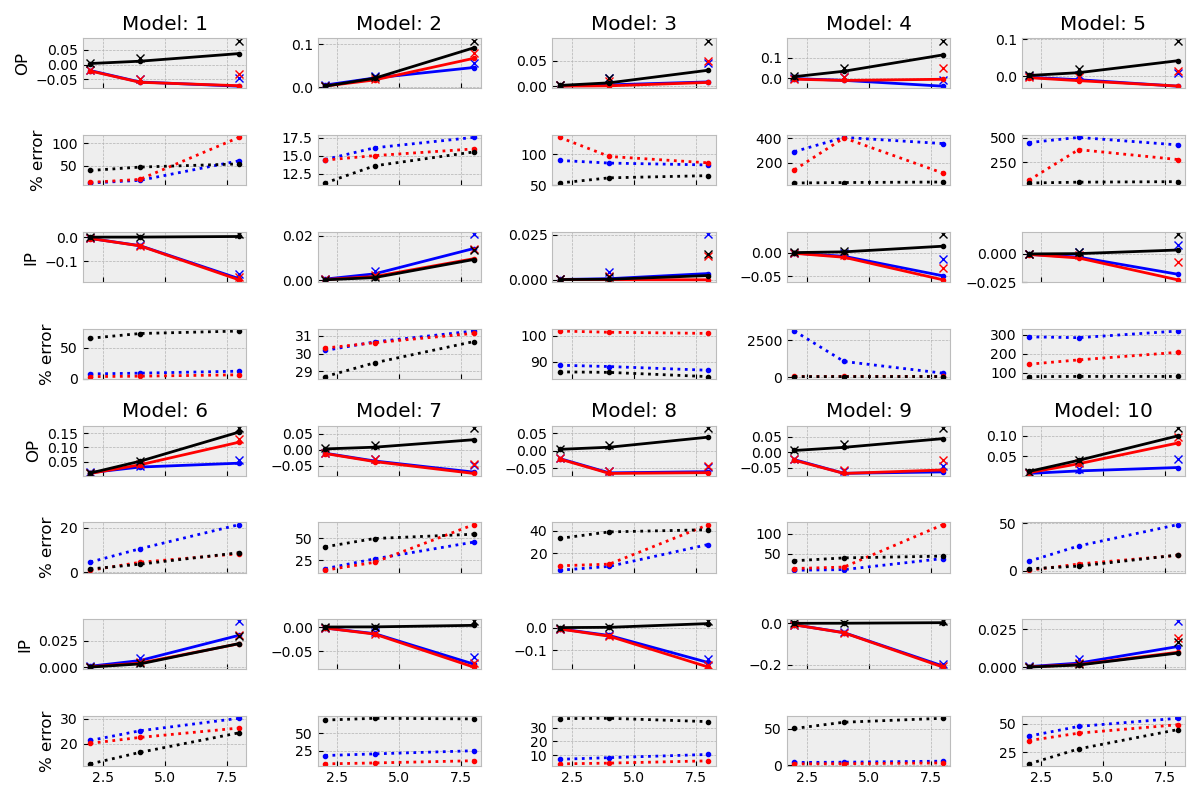

In [133]:
fig, ax = plt.subplots(8,5, figsize=(12,8), sharex=True, )

for i in range(5):
    ax[0,i].plot([2,4,8], random_data_pred[i,:3], '-b.') # hop
    ax[0,i].plot([2,4,8], random_data_OPIP[i,:3], 'xb')
    ax[0,i].plot([2,4,8], random_data_pred[i,6:9], '-r.') # vop
    ax[0,i].plot([2,4,8], random_data_OPIP[i,6:9], 'xr')
    ax[0,i].plot([2,4,8], random_data_pred[i,12:15], '-k.') # pop
    ax[0,i].plot([2,4,8], random_data_OPIP[i,12:15], 'xk')
   
  #  rmse = 100* np.sqrt(np.mean(((random_data_pred[i]-random_data_OPIP[i])/random_data_OPIP[i])**2))
    ax[0,i].set_title('Model: ' + str(i+1) ) #+ f' - % error: {rmse:.4f}', fontsize=8)

    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,:3]-random_data_OPIP[i,:3])/random_data_OPIP[i,:3])**2), '.:b')
    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,6:9]-random_data_OPIP[i,6:9])/random_data_OPIP[i,6:9])**2), '.:r')
    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,12:15]-random_data_OPIP[i,12:15])/random_data_OPIP[i,12:15])**2), '.:k')

    ax[2,i].plot([2,4,8], random_data_pred[i,3:6], '-b.') # hip
    ax[2,i].plot([2,4,8], random_data_OPIP[i,3:6], 'xb')
    ax[2,i].plot([2,4,8], random_data_pred[i,9:12], '-r.') # vip
    ax[2,i].plot([2,4,8], random_data_OPIP[i,9:12], 'xr')
    ax[2,i].plot([2,4,8], random_data_pred[i,15:], '-k.') # pip
    ax[2,i].plot([2,4,8], random_data_OPIP[i,15:], 'xk')

    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,3:6]-random_data_OPIP[i,3:6])/random_data_OPIP[i,3:6])**2), '.:b')
    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,9:12]-random_data_OPIP[i,9:12])/random_data_OPIP[i,9:12])**2), '.:r')
    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i,15:]-random_data_OPIP[i,15:])/random_data_OPIP[i,15:])**2), '.:k')

    ax[4,i].plot([2,4,8], random_data_pred[i+5,:3], '-b.') # hop
    ax[4,i].plot([2,4,8], random_data_OPIP[i+5,:3], 'xb')
    ax[4,i].plot([2,4,8], random_data_pred[i+5,6:9], '-r.') # vop
    ax[4,i].plot([2,4,8], random_data_OPIP[i+5,6:9], 'xr')
    ax[4,i].plot([2,4,8], random_data_pred[i+5,12:15], '-k.') # pop
    ax[4,i].plot([2,4,8], random_data_OPIP[i+5,12:15], 'xk')
#    rmse = 100* np.sqrt(np.mean(((random_data_pred[i]-random_data_OPIP[i])/random_data_OPIP[i])**2))
    ax[4,i].set_title('Model: ' + str(i+6) ) # + f' - % error: {rmse:.4f}', fontsize=8)

    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,:3]-random_data_OPIP[i+5,:3])/random_data_OPIP[i+5,:3])**2), '.:b')
    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,6:9]-random_data_OPIP[i+5,6:9])/random_data_OPIP[i+5,6:9])**2), '.:r')
    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,12:15]-random_data_OPIP[i+5,12:15])/random_data_OPIP[i+5,12:15])**2), '.:k')

    ax[6,i].plot([2,4,8], random_data_pred[i+5,3:6], '-b.') # hip
    ax[6,i].plot([2,4,8], random_data_OPIP[i+5,3:6], 'xb')
    ax[6,i].plot([2,4,8], random_data_pred[i+5,9:12], '-r.') # vip
    ax[6,i].plot([2,4,8], random_data_OPIP[i+5,9:12], 'xr')
    ax[6,i].plot([2,4,8], random_data_pred[i+5,15:], '-k.') # pip
    ax[6,i].plot([2,4,8], random_data_OPIP[i+5,15:], 'xk')

    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,3:6]-random_data_OPIP[i+5,3:6])/random_data_OPIP[i+5,3:6])**2), '.:b')
    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,9:12]-random_data_OPIP[i+5,9:12])/random_data_OPIP[i+5,9:12])**2), '.:r')
    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred[i+5,15:]-random_data_OPIP[i+5,15:])/random_data_OPIP[i+5,15:])**2), '.:k')

ax[0,0].set_ylabel('OP')
ax[1,0].set_ylabel('% error')
ax[2,0].set_ylabel('IP')
ax[3,0].set_ylabel('% error')

ax[4,0].set_ylabel('OP')
ax[5,0].set_ylabel('% error')
ax[6,0].set_ylabel('IP')
ax[7,0].set_ylabel('% error')

plt.tight_layout()

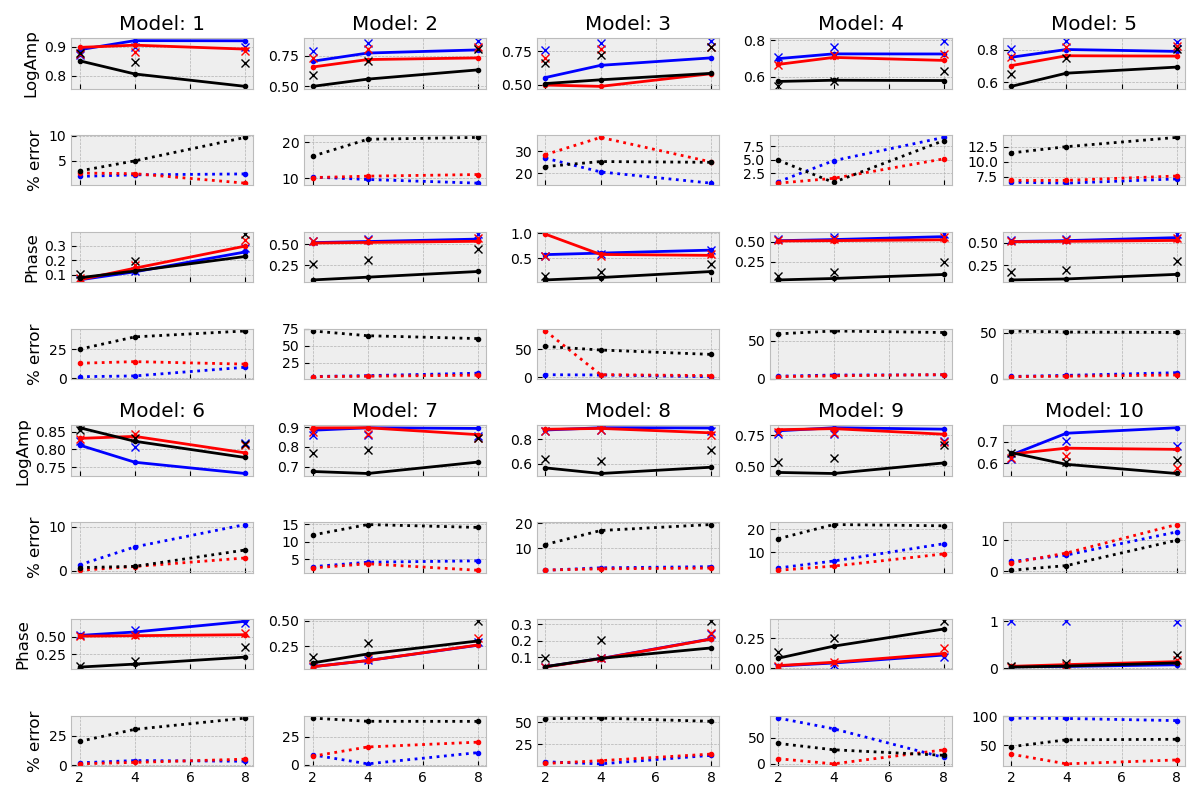

In [270]:
fig, ax = plt.subplots(8,5, figsize=(12,8), sharex=True, )

for i in range(5):
    ax[0,i].plot([2,4,8], random_data_pred_norm[i,:3], '-b.') # hAmp
    ax[0,i].plot([2,4,8], random_data[i,:3], 'xb')
    ax[0,i].plot([2,4,8], random_data_pred_norm[i,3:6], '-r.') # vAmp
    ax[0,i].plot([2,4,8], random_data[i,3:6], 'xr')
    ax[0,i].plot([2,4,8], random_data_pred_norm[i,6:9], '-k.') # pAmp
    ax[0,i].plot([2,4,8], random_data[i,6:9], 'xk')
   
  #  rmse = 100* np.sqrt(np.mean(((random_data_pred[i]-random_data_OPIP[i])/random_data_OPIP[i])**2))
    ax[0,i].set_title('Model: ' + str(i+1) ) #+ f' - % error: {rmse:.4f}', fontsize=8)

    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,:3]-random_data[i,:3])/random_data[i,:3])**2), '.:b')
    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,3:6]-random_data[i,3:6])/random_data[i,3:6])**2), '.:r')
    ax[1,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,6:9]-random_data[i,6:9])/random_data[i,6:9])**2), '.:k')

    ax[2,i].plot([2,4,8], random_data_pred_norm[i,9:12], '-b.') # hPha
    ax[2,i].plot([2,4,8], random_data[i,9:12], 'xb')
    ax[2,i].plot([2,4,8], random_data_pred_norm[i,12:15], '-r.') # vPha
    ax[2,i].plot([2,4,8], random_data[i,12:15], 'xr')
    ax[2,i].plot([2,4,8], random_data_pred_norm[i,15:], '-k.') # pPha
    ax[2,i].plot([2,4,8], random_data[i,15:], 'xk')

    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,9:12]-random_data[i,9:12])/random_data[i,9:12])**2), '.:b')
    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,12:15]-random_data[i,12:15])/random_data[i,12:15])**2), '.:r')
    ax[3,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i,15:]-random_data[i,15:])/random_data[i,15:])**2), '.:k')

    ax[4,i].plot([2,4,8], random_data_pred_norm[i+5,:3], '-b.') # hAmp
    ax[4,i].plot([2,4,8], random_data[i+5,:3], 'xb')
    ax[4,i].plot([2,4,8], random_data_pred_norm[i+5,3:6], '-r.') # vAmp
    ax[4,i].plot([2,4,8], random_data[i+5,3:6], 'xr')
    ax[4,i].plot([2,4,8], random_data_pred_norm[i+5,6:9], '-k.') # pAmp
    ax[4,i].plot([2,4,8], random_data[i+5,6:9], 'xk')
#    rmse = 100* np.sqrt(np.mean(((random_data_pred[i]-random_data_OPIP[i])/random_data_OPIP[i])**2))
    ax[4,i].set_title('Model: ' + str(i+6) ) # + f' - % error: {rmse:.4f}', fontsize=8)

    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,:3]-random_data[i+5,:3])/random_data[i+5,:3])**2), '.:b')
    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,3:6]-random_data[i+5,3:6])/random_data[i+5,3:6])**2), '.:r')
    ax[5,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,6:9]-random_data[i+5,6:9])/random_data[i+5,6:9])**2), '.:k')

    ax[6,i].plot([2,4,8], random_data_pred_norm[i+5,9:12], '-b.') # hPha
    ax[6,i].plot([2,4,8], random_data[i+5,9:12], 'xb')
    ax[6,i].plot([2,4,8], random_data_pred_norm[i+5,12:15], '-r.') # vPha
    ax[6,i].plot([2,4,8], random_data[i+5,12:15], 'xr')
    ax[6,i].plot([2,4,8], random_data_pred_norm[i+5,15:], '-k.') # pPha
    ax[6,i].plot([2,4,8], random_data[i+5,15:], 'xk')

    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,9:12]-random_data[i+5,9:12])/random_data[i+5,9:12])**2), '.:b')
    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,12:15]-random_data[i+5,12:15])/random_data[i+5,12:15])**2), '.:r')
    ax[7,i].plot([2,4,8], 100*np.sqrt(((random_data_pred_norm[i+5,15:]-random_data[i+5,15:])/random_data[i+5,15:])**2), '.:k')

ax[0,0].set_ylabel('LogAmp')
ax[1,0].set_ylabel('% error')
ax[2,0].set_ylabel('Phase')
ax[3,0].set_ylabel('% error')

ax[4,0].set_ylabel('LogAmp')
ax[5,0].set_ylabel('% error')
ax[6,0].set_ylabel('Phase')
ax[7,0].set_ylabel('% error')

#ax[0,4].legend(['H true', 'H pred', 'V true', 'V pred', 'P true', 'P pred'], loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Test with a different grid

In [58]:
# Create a model

sig1 = 10/1000
sig2 = 500/1000
sig3 = 10/1000
h1 = 2
h2 = np.linspace(1.5, 3.5)

mod_test = []

for h in h2:
    mod_test.append([h1, h, sig1, sig2, sig3])

mod_test = np.array(mod_test)

In [59]:
# Generate data

data = []

for m in mod_test:
    data.append(FDEM(m[2:], m[:2]))

In [60]:
# add noise to the data
data = np.array(data)

# add noise to data
noise_level = 0.0
noise = np.random.normal(loc=0.0, scale=noise_level, size = data.shape)
data_ = data * (1+noise)

In [61]:
# Convert to AmpPha

data_test = data_.copy()

data_AmpPha = np.zeros_like(data_test)

data_AmpPha[:,0], data_AmpPha[:,9] = OPIPtoAmpPha(data_test[:,0], data_test[:,3]) # h2
data_AmpPha[:,1], data_AmpPha[:,10] = OPIPtoAmpPha(data_test[:,1], data_test[:,4]) # h4
data_AmpPha[:,2], data_AmpPha[:,11] = OPIPtoAmpPha(data_test[:,2], data_test[:,5]) # h8

data_AmpPha[:,3], data_AmpPha[:,12] = OPIPtoAmpPha(data_test[:,6], data_test[:,9]) # v2
data_AmpPha[:,4], data_AmpPha[:,13] = OPIPtoAmpPha(data_test[:,7], data_test[:,10]) # v4
data_AmpPha[:,5], data_AmpPha[:,14] = OPIPtoAmpPha(data_test[:,8], data_test[:,11]) # v8

data_AmpPha[:,6], data_AmpPha[:,15] = OPIPtoAmpPha(data_test[:,12], data_test[:,15]) # v2
data_AmpPha[:,7], data_AmpPha[:,16] = OPIPtoAmpPha(data_test[:,13], data_test[:,16]) # v4
data_AmpPha[:,8], data_AmpPha[:,17] = OPIPtoAmpPha(data_test[:,14], data_test[:,17]) # v8

In [62]:
# Create a data norm dataframe

data_AmpPha_ = pd.DataFrame(data_AmpPha,
                             columns = ['h2amp', 'h4amp', 'h8amp', 'v2amp', 'v4amp', 'v8amp', 'p2amp', 'p4amp', 'p8amp',
                                        'h2pha', 'h4pha', 'h8pha', 'v2pha', 'v4pha', 'v8pha', 'p2pha', 'p4pha', 'p8pha',])

data_test_norm = scale_X.transform(data_AmpPha_)

In [63]:
# Predict models
#models_pred_norm = best_model.predict(data_test_norm)
models_pred_norm = np.column_stack([model.predict(data_test_norm) for model in best_models])
models_pred = 10**scale_y.inverse_transform(models_pred_norm)

In [64]:
# Regrid the test model

def grid(model, depthmax=8, ny=101, nlay=3):
    """ Generates a grid from the model to plot a 2D section
    """
    # Arrays for plotting
    npos = np.shape(model)[0] # number of 1D models
   # ny = 101 # size of the grid in y direction
    y = np.linspace(0, depthmax, ny) # y axis [m]
    grid = np.zeros((npos, ny)) # empty grid
    thk = model[:,:nlay-1].copy() # define electrical conductivities
    sig = model[:,nlay-1:].copy()  # define thicknesses
    
    # Fill the grid with the conductivity values
    
    if nlay == 3:
        for i in range(npos):
            y1 = 0
            # First layer
            while y[y1] < thk[i,0]:
                grid[i, y1] = sig[i, 0]
                y1 += 1
                if y1 > ny-1:
                    break
                #y2 = y1
            # Second layer
            while y[y1] < (thk[i,0] + thk[i,1]):
                grid[i, y1] = sig[i, 1]
                y1 += 1
                if y1 > ny-1:
                    break
            # Third layer
            grid[i, y1:] = sig[i, 2]

    return grid

def grid_6layer(model, depthmax=8, ny=101, nlay=9):
    """Generates a grid from the model to plot a 2D section for a 6-layer case.
    
    Parameters:
        model: ndarray of shape (npos, 11)
            Each row = [thk1, thk2, thk3, thk4, thk5, sig1, sig2, sig3, sig4, sig5, sig6]
        depthmax: float
            Maximum depth for the grid [m]
        ny: int
            Number of depth samples
        nlay: int
            Number of layers (must be 6 for this function)

    Returns:
        grid: ndarray of shape (npos, ny)
            Grid of conductivity values
    """
    npos = model.shape[0]  # number of 1D models
    y = np.linspace(0, depthmax, ny)  # depth axis [m]
    grid = np.zeros((npos, ny))  # initialize grid

    thk = model[:, :nlay-1]  # first 5 columns: thicknesses of top 5 layers
    sig = model[:, nlay-1:]  # last 6 columns: conductivities of 6 layers

    for i in range(npos):
        y1 = 0
        depth_accum = 0
        for j in range(nlay - 1):  # top 5 layers with defined thickness
            depth_next = depth_accum + thk[i, j]
            while y1 < ny and y[y1] < depth_next:
                grid[i, y1] = sig[i, j]
                y1 += 1
            depth_accum = depth_next
        # Last layer: infinite depth below total thickness
        grid[i, y1:] = sig[i, -1]

    return grid

In [65]:
mod_test_grid = grid(mod_test)

In [66]:
h1 = np.logspace(-0.3,0.35,8)

models_pred_th = []

for m in models_pred:
    models_pred_th.append(np.hstack((h1, m)))

models_pred_th = np.array(models_pred_th)

In [67]:
models_pred_grid = grid_6layer(models_pred_th)

In [68]:
# Calculate the data pred in OP and IP

data_pred = []

for m in models_pred:
    data_pred.append(FDEM(m, h1))

data_pred = np.array(data_pred)

In [69]:
mod_RMSE = np.sum(np.sqrt(np.abs((mod_test_grid.ravel() - models_pred_grid.ravel())/mod_test_grid.ravel())*100))/np.size(mod_test_grid)
dat_RMSE = np.sum(np.sqrt(np.abs((data_test.ravel() - data_pred.ravel())/data_test.ravel())*100))/np.size(data_test)

In [70]:
# Calculate grid of error

error_grid = np.sqrt(((mod_test_grid-models_pred_grid)/mod_test_grid)**2)

In [71]:
model_est_MC = np.load('model_est_9Lay_MC.npy')

model_est_MC_th = []

for m in model_est_MC:
    model_est_MC_th.append(np.hstack((h1, m)))

model_est_MC_th = np.array(model_est_MC_th)
model_est_MC_grid = grid_6layer(model_est_MC_th)

# Calculate the data pred in OP and IP

data_est_MC = []

for m in model_est_MC:
    data_est_MC.append(FDEM(m, h1))

data_est_MC = np.array(data_est_MC)

In [72]:
mod_est_RMSE = np.sum(np.sqrt(np.abs((mod_test_grid.ravel() - model_est_MC_grid.ravel())/mod_test_grid.ravel())*100))/np.size(mod_test_grid)
dat_est_RMSE = np.sum(np.sqrt(np.abs((data_test.ravel() - data_est_MC.ravel())/data_test.ravel())*100))/np.size(data_test)

Text(0.5, 0, 'Position [m]')

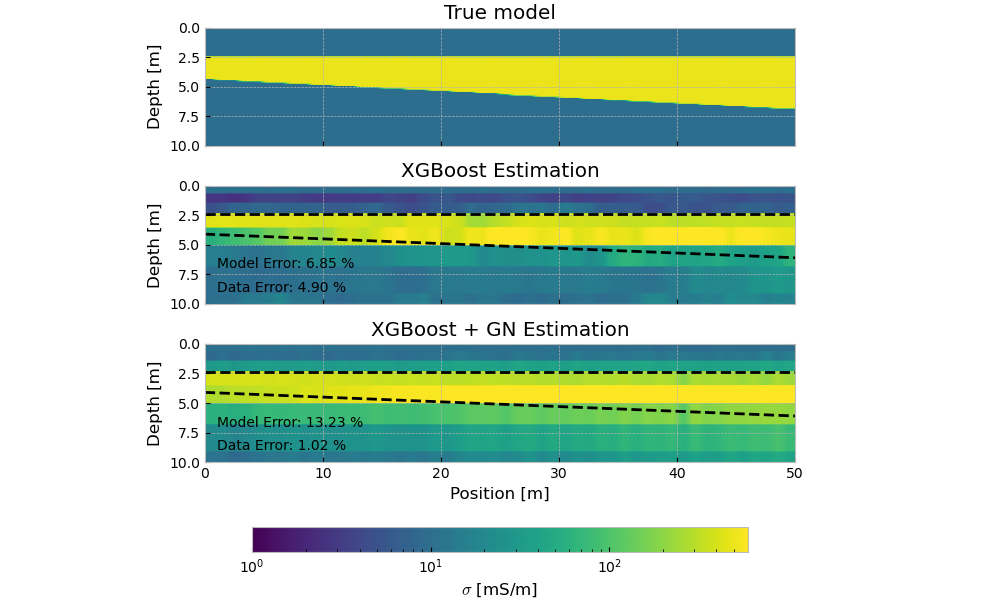

In [73]:
fig, ax = plt.subplots(3, figsize=(10,6), sharex=True, constrained_layout=True)

c = ax[0].imshow(mod_test_grid.T*1000, extent = [0,50,10,0], norm='log', vmin = 1, vmax=600)
ax[1].imshow(models_pred_grid.T*1000, extent= [0,50,10,0], norm='log', vmin = 1, vmax=600)
ax[2].imshow(model_est_MC_grid.T*1000, extent= [0,50,10,0], norm='log', vmin = 1, vmax=600)
ax[1].plot(np.linspace(0,50), mod_test[:,0]+.4, '--k')
ax[1].plot(np.linspace(0,50), mod_test[:,1]+ mod_test[:,0]+.6, '--k')

ax[2].plot(np.linspace(0,50), mod_test[:,0]+.4, '--k')
ax[2].plot(np.linspace(0,50), mod_test[:,1]+ mod_test[:,0]+.6, '--k')

ax[0].set_title('True model')
ax[1].set_title('XGBoost Estimation')
ax[2].set_title('XGBoost + GN Estimation')
ax[0].set_ylabel('Depth [m]')
ax[1].set_ylabel('Depth [m]')
ax[2].set_ylabel('Depth [m]')
fig.colorbar(c, ax=ax[:], label ='$\sigma$ [mS/m]', location ='bottom', shrink=0.5)

clr = 'k'
ax[1].text(1,7, f'Model Error: {mod_RMSE:.2f} %', c=clr, fontsize=10)
ax[1].text(1,9, f'Data Error: {dat_RMSE:.2f} %', c=clr,fontsize=10)

ax[2].text(1,7, f'Model Error: {mod_est_RMSE:.2f} %', c=clr, fontsize=10)
ax[2].text(1,9, f'Data Error: {dat_est_RMSE:.2f} %', c=clr, fontsize=10)

ax[2].set_xlabel('Position [m]')
#plt.tight_layout()
#plt.savefig('ModelMC.eps', format='eps')

Text(0.5, 0, 'Position [m]')

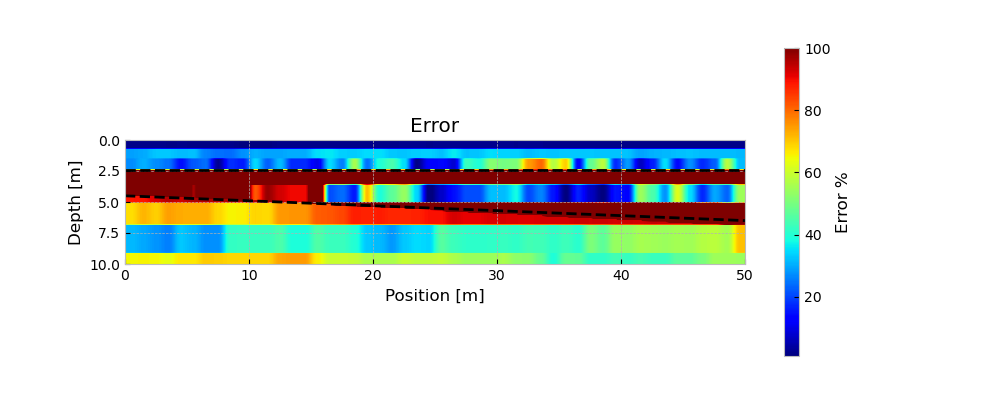

In [49]:
fig, ax = plt.subplots(figsize=(10,4), sharex=True)

c = ax.imshow(100*error_grid.T, extent = [0,50,10,0], cmap='jet', vmin=1, vmax=100)
ax.plot(np.linspace(0,50), mod_test[:,0]+.4, '--k')
ax.plot(np.linspace(0,50), mod_test[:,1]+ mod_test[:,0]+1, '--k')
ax.set_title('Error')
ax.set_ylabel('Depth [m]')
fig.colorbar(c, ax=ax, label ='Error %')
ax.set_xlabel('Position [m]')

/tmp/ipykernel_1337655/1254128053.py:191: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.92])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


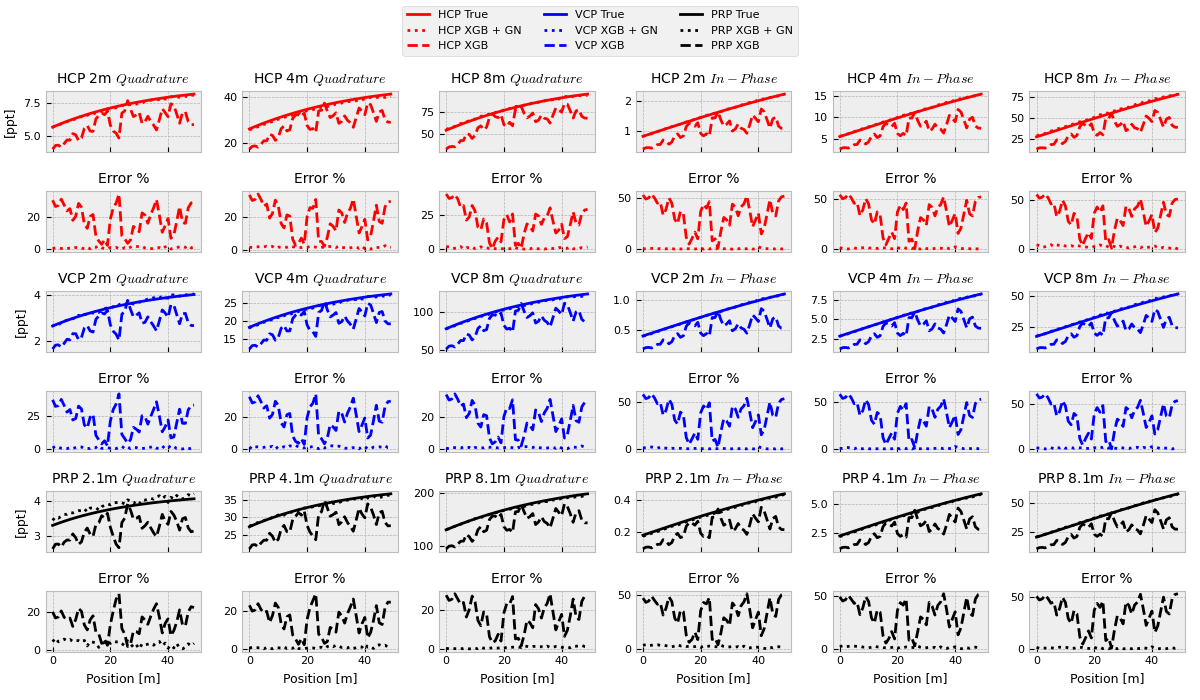

In [74]:
fig, ax = plt.subplots(6,6, figsize = (12,7), sharex=True, constrained_layout=True)

ax[0,0].plot(data_test[:,0]*1000, 'r', label='HCP True') 
ax[0,0].plot(data_est_MC[:,0]*1000, ':r', label='HCP XGB + GN') 
ax[0,0].plot(data_pred[:,0]*1000, '--r', label='HCP XGB') 
ax[2,0].plot(data_test[:,6]*1000, 'b', label='VCP True') 
ax[2,0].plot(data_est_MC[:,6]*1000, ':b', label='VCP XGB + GN') 
ax[2,0].plot(data_pred[:,6]*1000, '--b', label='VCP XGB') 
ax[4,0].plot(data_test[:,12]*1000, 'k', label='PRP True') 
ax[4,0].plot(data_est_MC[:,12]*1000, ':k', label='PRP XGB + GN') 
ax[4,0].plot(data_pred[:,12]*1000, '--k', label='PRP XGB') 
ax[0,0].set_title('HCP 2m $Quadrature$', fontsize=10)
ax[2,0].set_title('VCP 2m $Quadrature$', fontsize=10)
ax[4,0].set_title('PRP 2.1m $Quadrature$', fontsize=10)
ax[0,0].set_ylabel('[ppt]', fontsize=9)

ax[1,0].plot(np.sqrt(np.abs((data_test[:,0] - data_pred[:,0])/data_test[:,0])**2)*100, '--r')
ax[3,0].plot(np.sqrt(np.abs((data_test[:,6] - data_pred[:,6])/data_test[:,6])**2)*100, '--b')
ax[5,0].plot(np.sqrt(np.abs((data_test[:,12] - data_pred[:,12])/data_test[:,12])**2)*100, '--k')

ax[1,0].plot(np.sqrt(np.abs((data_test[:,0] - data_est_MC[:,0])/data_test[:,0])**2)*100, ':r')
ax[3,0].plot(np.sqrt(np.abs((data_test[:,6] - data_est_MC[:,6])/data_test[:,6])**2)*100, ':b')
ax[5,0].plot(np.sqrt(np.abs((data_test[:,12] - data_est_MC[:,12])/data_test[:,12])**2)*100, ':k')

ax[1,0].set_title('Error %', fontsize=10)
ax[3,0].set_title('Error %', fontsize=10)
ax[5,0].set_title('Error %', fontsize=10)

ax[0,1].plot(data_test[:,1]*1000, 'r', ) 
ax[0,1].plot(data_est_MC[:,1]*1000, ':r', ) 
ax[0,1].plot(data_pred[:,1]*1000, '--r', ) 
ax[2,1].plot(data_test[:,7]*1000, 'b', ) 
ax[2,1].plot(data_est_MC[:,7]*1000, ':b', ) 
ax[2,1].plot(data_pred[:,7]*1000, '--b', ) 
ax[4,1].plot(data_test[:,13]*1000, 'k', ) 
ax[4,1].plot(data_est_MC[:,13]*1000, ':k', ) 
ax[4,1].plot(data_pred[:,13]*1000, '--k', ) 
ax[0,1].set_title('HCP 4m $Quadrature$', fontsize=10)
ax[2,1].set_title('VCP 4m $Quadrature$', fontsize=10)
ax[4,1].set_title('PRP 4.1m $Quadrature$', fontsize=10)

ax[1,1].plot(np.sqrt(np.abs((data_test[:,1] - data_pred[:,1])/data_test[:,1])**2)*100, '--r')
ax[3,1].plot(np.sqrt(np.abs((data_test[:,7] - data_pred[:,7])/data_test[:,7])**2)*100, '--b')
ax[5,1].plot(np.sqrt(np.abs((data_test[:,13] - data_pred[:,13])/data_test[:,13])**2)*100, '--k')

ax[1,1].plot(np.sqrt(np.abs((data_test[:,1] - data_est_MC[:,1])/data_test[:,1])**2)*100, ':r')
ax[3,1].plot(np.sqrt(np.abs((data_test[:,7] - data_est_MC[:,7])/data_test[:,7])**2)*100, ':b')
ax[5,1].plot(np.sqrt(np.abs((data_test[:,13] - data_est_MC[:,13])/data_test[:,13])**2)*100, ':k')

ax[1,1].set_title('Error %', fontsize=10)
ax[3,1].set_title('Error %', fontsize=10)
ax[5,1].set_title('Error %', fontsize=10)

ax[0,2].plot(data_test[:,2]*1000, 'r', ) 
ax[0,2].plot(data_est_MC[:,2]*1000, ':r', ) 
ax[0,2].plot(data_pred[:,2]*1000, '--r', ) 
ax[2,2].plot(data_test[:,8]*1000, 'b', ) 
ax[2,2].plot(data_est_MC[:,8]*1000, ':b', ) 
ax[2,2].plot(data_pred[:,8]*1000, '--b', ) 
ax[4,2].plot(data_test[:,14]*1000, 'k', ) 
ax[4,2].plot(data_est_MC[:,14]*1000, ':k', ) 
ax[4,2].plot(data_pred[:,14]*1000, '--k', ) 
#ax[2,0].legend(fontsize=8)
ax[0,2].set_title('HCP 8m $Quadrature$', fontsize=10)
ax[2,2].set_title('VCP 8m $Quadrature$', fontsize=10)
ax[4,2].set_title('PRP 8.1m $Quadrature$', fontsize=10)
#ax[1,0].set_ylabel('[ppt]', fontsize=9)
ax[2,0].set_ylabel('[ppt]', fontsize=9)
#ax[3,0].set_ylabel('[ppt]', fontsize=9)
ax[4,0].set_ylabel('[ppt]', fontsize=9)
#ax[5,0].set_ylabel('[ppt]', fontsize=9)
#ax[2,0].set_xlabel('Position [m]', fontsize=9)

ax[1,2].plot(np.sqrt(np.abs((data_test[:,2] - data_pred[:,2])/data_test[:,2])**2)*100, '--r')
ax[3,2].plot(np.sqrt(np.abs((data_test[:,8] - data_pred[:,8])/data_test[:,8])**2)*100, '--b')
ax[5,2].plot(np.sqrt(np.abs((data_test[:,14] - data_pred[:,14])/data_test[:,14])**2)*100, '--k')

ax[1,2].plot(np.sqrt(np.abs((data_test[:,2] - data_est_MC[:,2])/data_test[:,2])**2)*100, ':r')
ax[3,2].plot(np.sqrt(np.abs((data_test[:,8] - data_est_MC[:,8])/data_test[:,8])**2)*100, ':b')
ax[5,2].plot(np.sqrt(np.abs((data_test[:,14] - data_est_MC[:,14])/data_test[:,14])**2)*100, ':k')

ax[1,2].set_title('Error %', fontsize=10)
ax[3,2].set_title('Error %', fontsize=10)
ax[5,2].set_title('Error %', fontsize=10)

ax[0,3].plot(data_test[:,3]*1000, 'r', ) 
ax[0,3].plot(data_est_MC[:,3]*1000, ':r', ) 
ax[0,3].plot(data_pred[:,3]*1000, '--r', ) 
ax[2,3].plot(data_test[:,9]*1000, 'b', ) 
ax[2,3].plot(data_est_MC[:,9]*1000, ':b', ) 
ax[2,3].plot(data_pred[:,9]*1000, '--b', ) 
ax[4,3].plot(data_test[:,15]*1000, 'k', ) 
ax[4,3].plot(data_est_MC[:,15]*1000, ':k', ) 
ax[4,3].plot(data_pred[:,15]*1000, '--k', ) 
#ax[0,1].legend(fontsize=8)

ax[0,3].set_title('HCP 2m $In-Phase$', fontsize=10)
ax[2,3].set_title('VCP 2m $In-Phase$', fontsize=10)
ax[4,3].set_title('PRP 2.1m $In-Phase$', fontsize=10)

ax[1,3].plot(np.sqrt(np.abs((data_test[:,3] - data_pred[:,3])/data_test[:,3])**2)*100, '--r')
ax[3,3].plot(np.sqrt(np.abs((data_test[:,9] - data_pred[:,9])/data_test[:,9])**2)*100, '--b')
ax[5,3].plot(np.sqrt(np.abs((data_test[:,15] - data_pred[:,15])/data_test[:,15])**2)*100, '--k')

ax[1,3].plot(np.sqrt(np.abs((data_test[:,3] - data_est_MC[:,3])/data_test[:,3])**2)*100, ':r')
ax[3,3].plot(np.sqrt(np.abs((data_test[:,9] - data_est_MC[:,9])/data_test[:,9])**2)*100, ':b')
ax[5,3].plot(np.sqrt(np.abs((data_test[:,15] - data_est_MC[:,15])/data_test[:,15])**2)*100, ':k')

ax[1,3].set_title('Error %', fontsize=10)
ax[3,3].set_title('Error %', fontsize=10)
ax[5,3].set_title('Error %', fontsize=10)

ax[0,4].plot(data_test[:,4]*1000, 'r', ) 
ax[0,4].plot(data_est_MC[:,4]*1000, ':r', ) 
ax[0,4].plot(data_pred[:,4]*1000, '--r', ) 
ax[2,4].plot(data_test[:,10]*1000, 'b', ) 
ax[2,4].plot(data_est_MC[:,10]*1000, ':b', ) 
ax[2,4].plot(data_pred[:,10]*1000, '--b', ) 
ax[4,4].plot(data_test[:,16]*1000, 'k', ) 
ax[4,4].plot(data_est_MC[:,16]*1000, ':k', ) 
ax[4,4].plot(data_pred[:,16]*1000, '--k', ) 
#ax[1,1].legend(fontsize=8)
ax[0,4].set_title('HCP 4m $In-Phase$', fontsize=10)
ax[2,4].set_title('VCP 4m $In-Phase$', fontsize=10)
ax[4,4].set_title('PRP 4.1m $In-Phase$', fontsize=10)

ax[1,4].plot(np.sqrt(np.abs((data_test[:,4] - data_pred[:,4])/data_test[:,4])**2)*100, '--r')
ax[3,4].plot(np.sqrt(np.abs((data_test[:,10] - data_pred[:,10])/data_test[:,10])**2)*100, '--b')
ax[5,4].plot(np.sqrt(np.abs((data_test[:,16] - data_pred[:,16])/data_test[:,16])**2)*100, '--k')

ax[1,4].plot(np.sqrt(np.abs((data_test[:,4] - data_est_MC[:,4])/data_test[:,4])**2)*100, ':r')
ax[3,4].plot(np.sqrt(np.abs((data_test[:,10] - data_est_MC[:,10])/data_test[:,10])**2)*100, ':b')
ax[5,4].plot(np.sqrt(np.abs((data_test[:,16] - data_est_MC[:,16])/data_test[:,16])**2)*100, ':k')

ax[1,4].set_title('Error %', fontsize=10)
ax[3,4].set_title('Error %', fontsize=10)
ax[5,4].set_title('Error %', fontsize=10)

ax[0,5].plot(data_test[:,5]*1000, 'r', ) 
ax[0,5].plot(data_est_MC[:,5]*1000, ':r', ) 
ax[0,5].plot(data_pred[:,5]*1000, '--r', ) 
ax[2,5].plot(data_test[:,11]*1000, 'b', ) 
ax[2,5].plot(data_est_MC[:,11]*1000, ':b', ) 
ax[2,5].plot(data_pred[:,11]*1000, '--b', ) 
ax[4,5].plot(data_test[:,17]*1000, 'k', ) 
ax[4,5].plot(data_est_MC[:,17]*1000, ':k', ) 
ax[4,5].plot(data_pred[:,17]*1000, '--k', ) 
#ax[2,1].legend(fontsize=8)
ax[0,5].set_title('HCP 8m $In-Phase$', fontsize=10)
ax[2,5].set_title('VCP 8m $In-Phase$', fontsize=10)
ax[4,5].set_title('PRP 8.1m $In-Phase$', fontsize=10)

ax[-1,0].set_xlabel('Position [m]', fontsize=9)
ax[-1,1].set_xlabel('Position [m]', fontsize=9)
ax[-1,2].set_xlabel('Position [m]', fontsize=9)
ax[-1,3].set_xlabel('Position [m]', fontsize=9)
ax[-1,4].set_xlabel('Position [m]', fontsize=9)
ax[-1,5].set_xlabel('Position [m]', fontsize=9)

ax[1,5].plot(np.sqrt(np.abs((data_test[:,5] - data_pred[:,5])/data_test[:,5])**2)*100, '--r')
ax[3,5].plot(np.sqrt(np.abs((data_test[:,11] - data_pred[:,11])/data_test[:,11])**2)*100, '--b')
ax[5,5].plot(np.sqrt(np.abs((data_test[:,17] - data_pred[:,17])/data_test[:,17])**2)*100, '--k')

ax[1,5].plot(np.sqrt(np.abs((data_test[:,5] - data_est_MC[:,5])/data_test[:,5])**2)*100, ':r')
ax[3,5].plot(np.sqrt(np.abs((data_test[:,11] - data_est_MC[:,11])/data_test[:,11])**2)*100, ':b')
ax[5,5].plot(np.sqrt(np.abs((data_test[:,17] - data_est_MC[:,17])/data_test[:,17])**2)*100, ':k')

ax[1,5].set_title('Error %', fontsize=10)
ax[3,5].set_title('Error %', fontsize=10)
ax[5,5].set_title('Error %', fontsize=10)

for a in ax.ravel():
    a.tick_params(labelsize=8)

    #ax[0,-1].legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
    
#fig.suptitle('Data Fit')

from collections import OrderedDict
# Collect all handles and labels
handles, labels = [], []
for a in ax.flat:
    h, l = a.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Deduplicate by label using OrderedDict
by_label = OrderedDict(zip(labels, handles))

# Create a single legend for the figure
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.legend(by_label.values(), by_label.keys(),
           loc='upper center', ncol=3,  fontsize=8)

plt.savefig('Data_9L_MC.eps', format='eps')

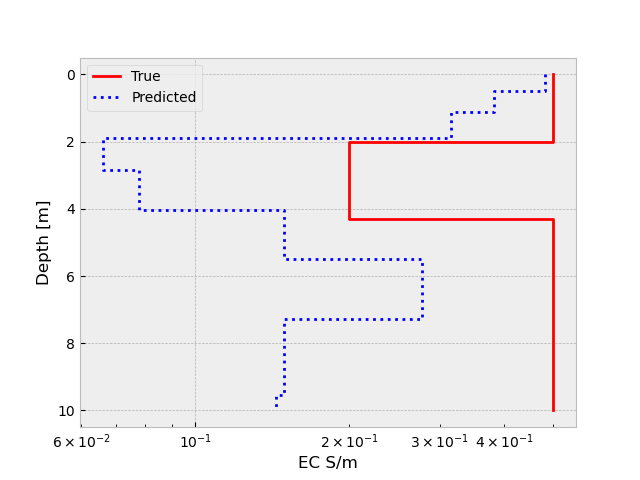

In [160]:
# Check results in a specific position

i = 20
fig, ax = plt.subplots()

ax.step(np.hstack((mod_test[i,2:], mod_test[i,-1])), np.hstack(([[0], np.cumsum(mod_test[i, :2]), [10]])) , 'r', label = 'True')
ax.step(np.hstack((models_pred[i], models_pred[i,-1])), np.hstack(([[0], np.cumsum(h1), [10]])), ':b', label='Predicted', )
ax.legend()
ax.set_xscale('log')
ax.set_xlabel('EC S/m')
ax.set_ylabel('Depth [m]')
ax.invert_yaxis()

In [72]:
# Save model
#joblib.dump(best_model, 'best_xgb_model_300est_maxdep13_30it_40cv_9Layers.pkl')

In [251]:
# save results

noise = 1

np.save('models_pred_9Lay_MR_'+str(noise), models_pred)
np.save('data_pred_9Lay_MR_'+str(noise), data_test)
#np.save('model_true_9Lay_MC', models_test)


In [ ]:
# Field case

